# Проект: Линейные модели в машинном обучении

**Описание проекта**

Вы работаете в IT-компании, которая выполняет на заказ проекты по машинному обучению. К вам обратился фермер, владелец молочного хозяйства «Вольный луг». Он хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма».

Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по его критериям, ничуть не хуже. А продавцы и технологи так и норовят приукрасить своих коровок!

Поэтому он просит вас разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах. Вам нужно создать две прогнозные модели для отбора бурёнок в поголовье:
1. Первая будет прогнозировать возможный удой коровы (целевой признак `Удой`);
2. Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак `Вкус молока`).

С помощью модели нужно отобрать коров по двум критериям:
- средний удой за год — не менее 6000 килограммов;
- молоко должно быть вкусным.

**Импортируем все необходимые библиотеки для исследования:**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score, precision_score
from scipy.stats import sem, norm

## 1. Загрузка данных

#### Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы.

Путь к файлам:
- `/datasets/ferma_main.csv`
- `/datasets/ferma_dad.csv`
- `/datasets/cow_buy.csv`

In [2]:
ferma_main = pd.read_csv('/datasets/ferma_main.csv')
ferma_dad = pd.read_csv('/datasets/ferma_dad.csv')
cow_buy = pd.read_csv('/datasets/cow_buy.csv')

#### Выведем первые строки наборов данных. Изучим общую информацию о датафреймах.

Выведем первые 5 строк датафреймов:

In [3]:
ferma_main.head()

,id;Удой,кг;ЭКЕ (Энергетическая кормовая единица);Сырой протеин,г;СПО (Сахаро-протеиновое соотношение);Порода;Тип пастбища;порода папы_быка;Жирность,%;Белок,%;Вкус молока;Возраст
0,1;5863;14,2;1743;0,89;Вис Бик Айдиал;Равнинное;Айдиал;3,58;3,076;вкусно;более_2_лет
1,2;5529;12,8;2138;0,89;Вис Бик Айдиал;Равнинные;Соверин;3,54;3,079;вкусно;менее_2_лет
2,3;5810;14;1854;0,885;РефлешнСоверинг;Холмистое;Соверин;3,59;3,074;не вкусно;более_2_лет,NaN
3,4;5895;12,4;2012;0,885;РефлешнСоверинг;Холмистое;Айдиал;3,4;3,075;не вкусно;более_2_лет
4,5;5302;12,8;1675;0,885;Вис Бик Айдиал;Равнинные;Соверин;3,73;3,073;вкусно;менее_2_лет


In [4]:
ferma_dad.head()

,id;Имя Папы
0,1;Буйный
1,2;Соловчик
2,3;Барин
3,4;Буйный
4,5;Барин


In [5]:
cow_buy.head()

,Порода;Тип пастбища;порода папы_быка;Имя_папы;Текущая_жирность,%;Текущий_уровень_белок,%;Возраст
0,Вис Бик Айдиал;холмистое;Айдиал;Геркулес;3,58;3,076;более_2_лет
1,Вис Бик Айдиал;равнинное;Соверин;Буйный;3,54;3,081;менее_2_лет
2,РефлешнСоверинг;равнинное;Соверин;Барин;3,59;3,074;более_2_лет
3,РефлешнСоверинг;холмистое;Айдиал;Буйный;3,4;3,061;более_2_лет
4,РефлешнСоверинг;равнинное;Айдиал;Буйный;3,64;3,074;более_2_лет


Из вывода датафреймов можно сказать, что разделяющим параметром *не является запятая*, как в большинстве случаев, поэтому в качестве передаваемого параметра аргументу `sep` нужно передать `;`, так как именно он является *разделяющим* в нашем csv-файле.

Проделаем те же самые шаги, но теперь при считывании файла зададим параметр `sep=';'`:

In [6]:
ferma_main = pd.read_csv('/datasets/ferma_main.csv', sep=';')
ferma_dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';')
cow_buy = pd.read_csv('/datasets/cow_buy.csv', sep=';')

In [7]:
ferma_main.head()

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [8]:
ferma_dad.head()

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [9]:
cow_buy.head()

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


Теперь можно говорить о том, что CSV-файлы считались правильно, и с такими датафреймами уже можно работать.

#### Изучим общую информацию о датафреймах

Теперь для лучшего понимания данных, хранящихся в датафреймах, выведем информацию о них методом `.info()`:

In [10]:
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11  Возраст            

In [11]:
ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [12]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


Из представленной информации о датафреймах можно сказать следующее: в данных нет нулевых строк, названия столбцов *необходимо изменить*, так как они не  соответствуют общепринятым нормам записи - нижний регистр, "змеевидный" тип записи, латинский алфавит. 

Также стоит отметить несоответсвие в типах данных у столбцов в некоторых датафреймах:
- датафрейм `ferma_main`: столбцы `ЭКЕ (Энергетическая кормовая единица)`, `СПО (Сахаро-протеиновое соотношение)`, `Жирность,%`, `Белок,%`;
- датафрейм `cow_buy`: столбцы `Текущая_жирность,%`, `Текущий_уровень_белок,%`.

Стоит отметить также и такую делать, как данные в столбцах, которые необходимо будет преобразовать: на первый взгляд это незаметно, но вещественные числа должны быть записаны через точку - `'.'`, а не запятую - `','`. Если не преобразовать их, то в дальннейшем будет возникать огромное количество ошибок.

Поэтапно обработаем каждое из этих несоответствий.

#### Изменение названия столбцов

Так как у нас 3 датафрейма и каждый раз повторять одни и те же шаги неразумно, то для оптимизации процесса создадим функцию `rename_columns`, которая будет принимать датафрейм и преобразовывать названия столбцов на правильные. 

Опишем алгоритм работы функции: функция `rename_columns` принимает датафрейм `dataframe`, после этого текущие названия столбцов переданного датафрейма записываются в переменную `old_names`, также создаётся пустой список `new_names`, куда будут записываться измененные названия; после циклом *for* пройдёмся по данным в `old_names` и методом `.lower()` преобразуем их к строчному виду, после добавим результат в `new_names` методом `.append()`; далее снова воспользуемся циклом *for* и постепенно будем изменять старые названия на новые; в конце функции вернём полученный датафрейм

In [13]:
# функция преобразования названия столбцов
def rename_columns(dataframe):
    # текущие названия
    old_names = dataframe.columns
    new_names = []
    for i in range (len(old_names)):
        new_names.append(old_names[i].lower())
    for i in range(len(new_names)):
        dataframe = dataframe.rename(columns={old_names[i] : new_names[i]})
    return dataframe

Воспользуемся написанной функцией для преобразования названия столбцов в датафреймах:

In [14]:
ferma_main = rename_columns(ferma_main)
ferma_dad = rename_columns(ferma_dad)
cow_buy = rename_columns(cow_buy)

Теперь приведём названия столбцов к "змеевидному" типу:

In [15]:
ferma_main.columns = ['id', 'milk_yield', 'eke',
       'raw_protein', 'spo', 'breed',
       'pasture_type', 'pasture_breed_dad', 'fat_content', 'protein',
       'taste_of_milk', 'age']
# 'eke' - эке(энергетическая_кормовая_единица), 'breed' - 'порода', 'pasture_type' - 'тип_пастбища', 
# 'pasture_breed_dad' - 'порода_папы_быка','spo' - спо(сахаро-протеиновое_соотношение), 'fat_content' - 'жирность,%', 
# 'protein' - 'белок,%'

In [16]:
ferma_dad.columns = ['id', 'dad_name']

In [17]:
cow_buy.columns = ['breed', 'pasture_type', 'pasture_breed_dad', 'dad_name',
       'fat_content', 'protein', 'age']
# 'breed' - 'порода', 'pasture_type' - 'тип_пастбища', 'pasture_breed_dad' - 'порода_папы_быка', 'dad_name' - 'имя_папы',
# 'fat_content' - 'текущая_жирность,%', 'protein' - 'текущий_уровень_белок,%', 'age' - 'возраст'

Теперь выведем снова общую информацию, после проведённых операций.

Создадим функцию, которая это делает, так как это будет удобнее чем 3 раза писать одно и тоже:

In [18]:
def dataframes_info(df_1, df_2, df_3):
    print('\nДатафрейм ferma_main\n')
    df_1.info()
    print('\nДатафрейм ferma_dad\n')
    df_2.info()
    print('\nДатафрейм cow_buy\n')
    df_3.info()

In [19]:
# Выводим общую информацию с помощью функции dataframes_info()
dataframes_info(ferma_main, ferma_dad, cow_buy)


Датафрейм ferma_main

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 634 non-null    int64 
 1   milk_yield         634 non-null    int64 
 2   eke                634 non-null    object
 3   raw_protein        634 non-null    int64 
 4   spo                634 non-null    object
 5   breed              634 non-null    object
 6   pasture_type       634 non-null    object
 7   pasture_breed_dad  634 non-null    object
 8   fat_content        634 non-null    object
 9   protein            634 non-null    object
 10  taste_of_milk      634 non-null    object
 11  age                634 non-null    object
dtypes: int64(3), object(9)
memory usage: 59.6+ KB

Датафрейм ferma_dad

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 

**Промежуточный вывод:**

В результате загрузки данных были выполнены следующие шаги:
- загрузили CSV-файлы с правильным разделяющим параметром
- изучили основную информацию о датафреймах
- изменили названия столбцов - привели к правильному виду записи (латинский алфавит, прописные буквы, "змеевидная" запись(через нижнее подчеркивание))
- было определено, что необходимо преобразовать типы данных некоторых столбцов датафреймов(проделаем это в следующем шаге)


## 2. Предобработка данных

#### Преобразование данных в нужные типы

Как ранее было замечено, в некоторых датафреймах тип данных столбцов не соответствует нужному, поэтому преобразуем их. Для удобства также создадим функцию.

In [20]:
# функция преобразования типа данных
def retype_columns(dataframe, name_list):
    for i in name_list:
        # заменяем запятые в строках с данными на точки
        dataframe[i] = dataframe[i].str.replace(',','.')
        # преобразовываем данные столбца в вещественный тип
        dataframe[i] = dataframe[i].astype('float64')
    return dataframe

Создадим списки `name_columns` и `name_columns_2`, в которых будут храниться названия столбцов, необходимых для преобразования типа в датафреймах `ferma_main` и `cow_buy` соответственно, а после воспользуемся функцией `retype_columns()`:

In [21]:
name_columns = ['eke','spo','fat_content', 'protein']
name_columns_2 = ['fat_content', 'protein']
ferma_main = retype_columns(ferma_main, name_columns)
cow_buy = retype_columns(cow_buy, name_columns_2)

Функцией `dataframes_info` проверим все преобразования данных, которые были проделаны:

In [22]:
dataframes_info(ferma_main, ferma_dad, cow_buy)


Датафрейм ferma_main

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 634 non-null    int64  
 1   milk_yield         634 non-null    int64  
 2   eke                634 non-null    float64
 3   raw_protein        634 non-null    int64  
 4   spo                634 non-null    float64
 5   breed              634 non-null    object 
 6   pasture_type       634 non-null    object 
 7   pasture_breed_dad  634 non-null    object 
 8   fat_content        634 non-null    float64
 9   protein            634 non-null    float64
 10  taste_of_milk      634 non-null    object 
 11  age                634 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 59.6+ KB

Датафрейм ferma_dad

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column

Из результатов вывода видно, что все проведённые преобразования были выполнены: столбы изменили названия на "правильные", определённые столбцы изменили тип данных на нужный.

#### Обработаем пропуски в данных

Воспользуемся методом `.isna()` для поиска пропусков во всех датафреймах и просуммируем их методом `.sum()`:

In [23]:
ferma_main.isna().sum()

id                   0
milk_yield           0
eke                  0
raw_protein          0
spo                  0
breed                0
pasture_type         0
pasture_breed_dad    0
fat_content          0
protein              0
taste_of_milk        0
age                  0
dtype: int64

In [24]:
ferma_dad.isna().sum()

id          0
dad_name    0
dtype: int64

In [25]:
cow_buy.isna().sum()

breed                0
pasture_type         0
pasture_breed_dad    0
dad_name             0
fat_content          0
protein              0
age                  0
dtype: int64

Из представленных результатов видно, что пропусков в данных нет, что является *хорошим* показателем.

#### Проверим данные на наличие дубликатов

После проверки датафрейма на наличие пропусков, проверим его на наличие дубликатов:

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество:

In [26]:
ferma_main.duplicated().sum()

5

In [27]:
ferma_dad.duplicated().sum()

0

In [28]:
cow_buy.duplicated().sum()

4

В результате наблюдаем, что дубликаты есть только в датафреймах `ferma_main` и `cow_buy`. Проверим их, то есть выведем их на экран и решим удалять их или нет, так как датафреймы не очень большие и они могут быть существены.

In [29]:
ferma_main[ferma_main.duplicated() == True]

,id,milk_yield,eke,raw_protein,spo,breed,pasture_type,pasture_breed_dad,fat_content,protein,taste_of_milk,age
629,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
630,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
631,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
632,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
633,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет


In [30]:
cow_buy[cow_buy.duplicated() == True]

,breed,pasture_type,pasture_breed_dad,dad_name,fat_content,protein,age
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
14,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
19,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


In [31]:
cow_buy

,breed,pasture_type,pasture_breed_dad,dad_name,fat_content,protein,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет


Из анализа этих дубликатов можно говорить следующее: удалим эти дубликаты, так как они повторяют уже имеющиеся. 

С помощью метода `.drop_duplicates()` удалим дубликаты, параметру `keep` передадим значение `'first'` - оставим первые входящие в датафрейм строки с информацией, a параметру `subset` - `'id'` для датафрейма `ferma_main`. С датафреймом `cow_buy` немного сложнее: из-за того, что в большинстве его столбцов данные о категории и количественные переменные тоже могут повторяться, то удалять дубликаты прошлым методом нельзя; поэтому запишем в `cow_buy` те строки, в которым метод `.duplicated()` показал значение `False`. После всех удалений сделаем переиндексацию без сохранения предыдущей:

In [32]:
ferma_main = ferma_main.drop_duplicates(subset=['id'], keep='first').reset_index(drop=True)
cow_buy = cow_buy[cow_buy.duplicated() == False].reset_index(drop=True)

Проверим  датафреймы ещё раз:

In [33]:
ferma_main.duplicated().sum()

0

In [34]:
cow_buy.duplicated().sum()

0

Теперь проверим данные на наличие *неявных* дубликатов, которые также могут встретиться. Для этого необходимо будет проверить все категориальные столбцы с данными на уникальность методом `.unique()`. Так как столбцов с данными много, то для оптимизации работы напишем функцию `unique_search()`: в неё будем передавать датафрейм, его имя(строкой) и названия столбцов категориальных переменных:

In [35]:
def unique_search(dataframe, df_name , data_list):
    for i in data_list:
        print('\nДатафрейм ' + df_name + ', столбец ' + i + ':\n')
        print(dataframe[i].unique())

Применим функцию `unique_search()` к датафреймам `ferma_main`, `cow_buy` и после проанализируем результаты вывода:

In [36]:
unique_search(ferma_main, 'ferma_main', ferma_main.drop(columns = ferma_main.describe().columns).columns)


Датафрейм ferma_main, столбец breed:

['Вис Бик Айдиал' 'РефлешнСоверинг']

Датафрейм ferma_main, столбец pasture_type:

['Равнинное' 'Равнинные' 'Холмистое']

Датафрейм ferma_main, столбец pasture_breed_dad:

['Айдиал' 'Соверин' 'Айдиалл']

Датафрейм ferma_main, столбец taste_of_milk:

['вкусно' 'не вкусно']

Датафрейм ferma_main, столбец age:

['более_2_лет' 'менее_2_лет']


In [37]:
unique_search(cow_buy, 'cow_buy', cow_buy.drop(columns = cow_buy.describe().columns).columns)


Датафрейм cow_buy, столбец breed:

['Вис Бик Айдиал' 'РефлешнСоверинг']

Датафрейм cow_buy, столбец pasture_type:

['холмистое' 'равнинное']

Датафрейм cow_buy, столбец pasture_breed_dad:

['Айдиал' 'Соверин']

Датафрейм cow_buy, столбец dad_name:

['Геркулес' 'Буйный' 'Барин' 'Соловчик']

Датафрейм cow_buy, столбец age:

['более_2_лет' 'менее_2_лет']


Из результатов проверки на уникальность видно, что есть данные в столбцах, которые написаны либо не правильно, либо обозначающие одно и тоже. Заменим их методом `.replace()`:

In [38]:
# замена ошибочных или повторных данных в столбцах датафреймов
ferma_main['pasture_breed_dad'] = ferma_main['pasture_breed_dad'].replace('Айдиалл','Айдиал')
ferma_main['pasture_type'] = ferma_main['pasture_type'].replace('Равнинные','Равнинное')
ferma_main['taste_of_milk'] = ferma_main['taste_of_milk'].replace('не вкусно','не_вкусно')
ferma_main['breed'] = ferma_main['breed'].replace('Вис Бик Айдиал','Вис_Бик_Айдиал')
cow_buy['breed'] = cow_buy['breed'].replace('Вис Бик Айдиал','Вис_Бик_Айдиал')
# приведём данные столбца 'pasture_type' к нижнему регистру в датафрейме ferma_main
ferma_main['pasture_type'] = ferma_main['pasture_type'].apply(lambda x: x.lower())

Снова вызовем функцию `unique_search()` для проверки уникальности, после нашим преобразований:

In [39]:
unique_search(ferma_main, 'ferma_main', ferma_main.drop(columns = ferma_main.describe().columns).columns)


Датафрейм ferma_main, столбец breed:

['Вис_Бик_Айдиал' 'РефлешнСоверинг']

Датафрейм ferma_main, столбец pasture_type:

['равнинное' 'холмистое']

Датафрейм ferma_main, столбец pasture_breed_dad:

['Айдиал' 'Соверин']

Датафрейм ferma_main, столбец taste_of_milk:

['вкусно' 'не_вкусно']

Датафрейм ferma_main, столбец age:

['более_2_лет' 'менее_2_лет']


In [40]:
unique_search(cow_buy, 'cow_buy', cow_buy.drop(columns = cow_buy.describe().columns).columns)


Датафрейм cow_buy, столбец breed:

['Вис_Бик_Айдиал' 'РефлешнСоверинг']

Датафрейм cow_buy, столбец pasture_type:

['холмистое' 'равнинное']

Датафрейм cow_buy, столбец pasture_breed_dad:

['Айдиал' 'Соверин']

Датафрейм cow_buy, столбец dad_name:

['Геркулес' 'Буйный' 'Барин' 'Соловчик']

Датафрейм cow_buy, столбец age:

['более_2_лет' 'менее_2_лет']


Видно, что изменения были успешно выполнены.

**Промежуточный вывод:**

В результате предобработки данных были выполнены следующие шаги:
- преобразовали тип данных столбцов датафреймов `ferma_main` и `cow_buy` к нужному
- обработаны пропуски в столбцах датафреймов - выявили, что их нет
- проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
- удалили дубликаты, которые было возможно

## 3. Исследовательский анализ данных

#### Проведём статистический анализ всех признаков

Как ранее можно было заметить в датафреймах присутствуют как категориальные, так и количественные переменные. В связи с эти требуется отдельная обработка для данных каждого типа.

**Рассмотрим количественные переменные**

Воспользуемся методом `.describe()` для того, что вывести все признаки количественных переменных в датафреймах. Переменные данного типа отсутствуют в датафрейме `ferma_dad`, поэтому необходимости в вызове данного метода к нему - *нет*.

In [41]:
ferma_main.describe()

,id,milk_yield,eke,raw_protein,spo,fat_content,protein
count,629.00000,629.000000,629.000000,629.000000,629.000000,629.000000,629.000000
mean,315.00000,6188.750397,14.543879,1923.364070,0.913116,3.603657,3.075671
std,181.72094,1644.795489,1.306408,182.956251,0.032203,0.168656,0.002549
min,1.00000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.00000,5751.000000,13.500000,1771.000000,0.890000,3.590000,3.074000
50%,315.00000,6133.000000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.00000,6501.000000,15.600000,2062.000000,0.940000,3.720000,3.077000
max,629.00000,45616.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


In [42]:
cow_buy.describe()

,fat_content,protein
count,16.000000,16.000000
mean,3.571875,3.068250
std,0.141620,0.011264
min,3.340000,3.046000
25%,3.415000,3.059500
50%,3.585000,3.073500
75%,3.692500,3.076750
max,3.770000,3.081000


Из представленных описательных характеристик можно говорить о том, что данные, в принципе, довольно хорошо представлены, можно конечно заметить, что в столбце `milk_yield,kg` датафрейма `ferma_main` значения 75% и максимальное отличаются почти на 40000, скорее всего можно говорить о том, что это выброс, который необходимо будет обработать; проверим это в дальнейшем при построении диаграммы размаха("ящик с усами").

Для упрощения работы создадим функцию `counting_param()`, которая будет визуализировать гистограмму и "ящик с усами" в зависимости от передаваемых параметров:

In [43]:
# функция визуализации графиков
# в функцию передаётся: датафрейм, столбец датафрейма, название оси Х, название оси У
def counting_param(dataframe, columns, measure_x, measure_y):
    plt.figure(figsize=(20, 15))
    # Вывод графиков
    plt.subplot(2, 2, 1)
    # Шаблон для построения гистограммы
    dataframe[columns].plot(kind='hist', bins=50, grid=True)
    plt.xlabel(measure_x)
    plt.ylabel(measure_y)
    plt.subplot(2, 2, 2)
    # Шаблон для построения "ящика с усами"
    dataframe.boxplot(column=[columns])
    plt.xticks([])
    plt.ylabel(measure_x)

Теперь вызовем эту функцию к каждому столбцу датафрейма `ferma_main`, содержащим количественные переменные: 

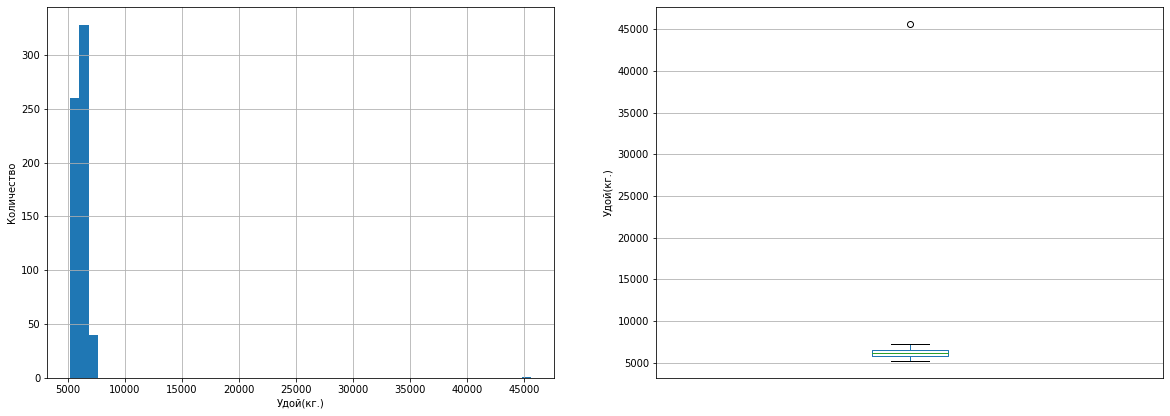

In [44]:
counting_param(ferma_main, 'milk_yield', 'Удой(кг.)','Количество')

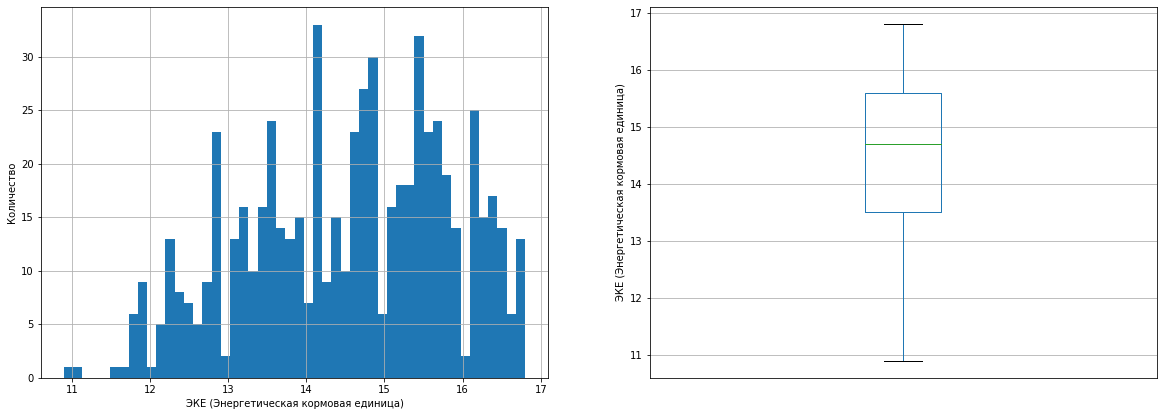

In [45]:
counting_param(ferma_main, 'eke', 'ЭКЕ (Энергетическая кормовая единица)','Количество')

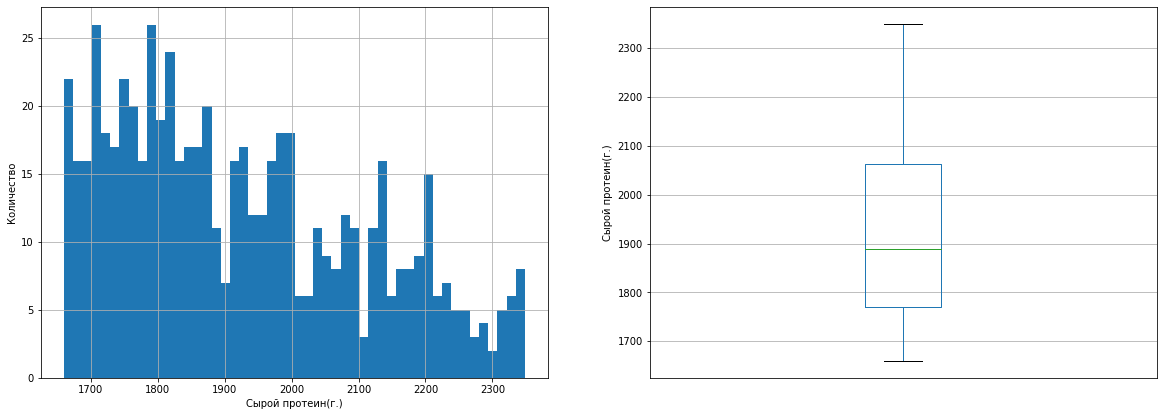

In [46]:
counting_param(ferma_main, 'raw_protein', 'Сырой протеин(г.)','Количество')

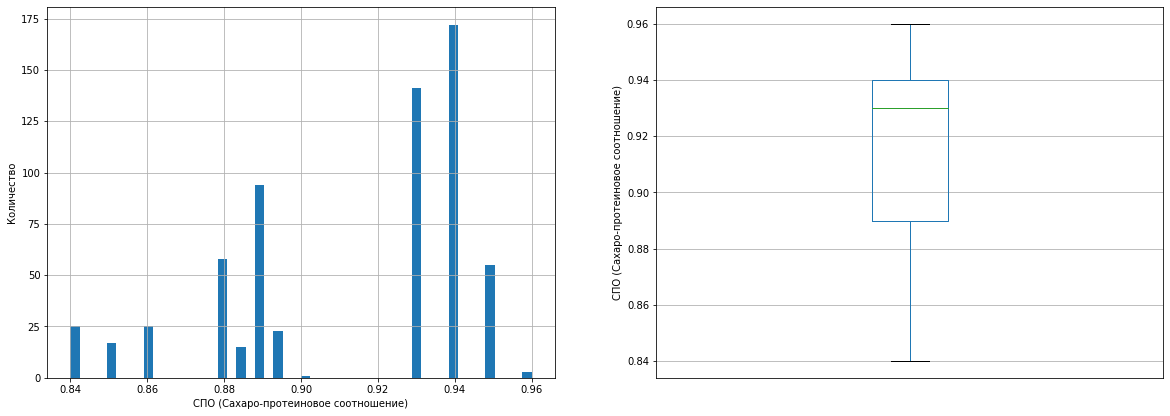

In [47]:
counting_param(ferma_main, 'spo', 'СПО (Сахаро-протеиновое соотношение)','Количество')

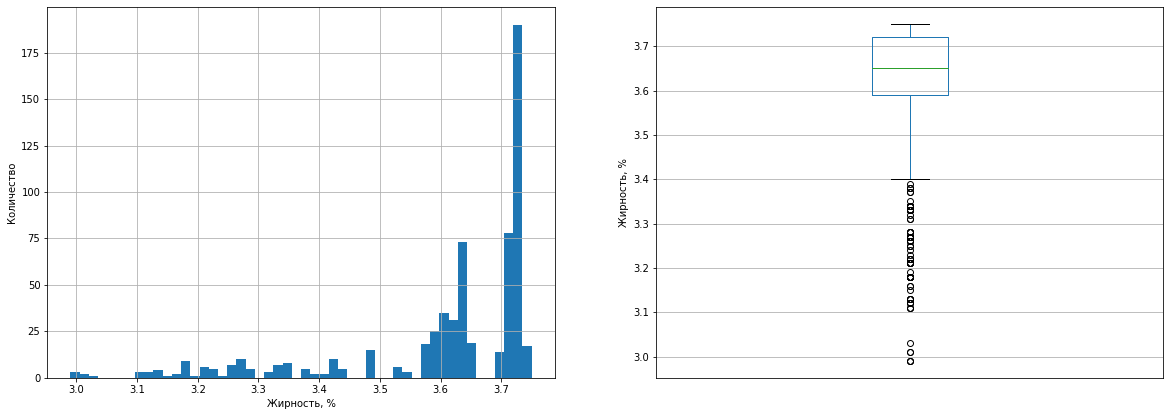

In [48]:
counting_param(ferma_main, 'fat_content', 'Жирность, %','Количество' )

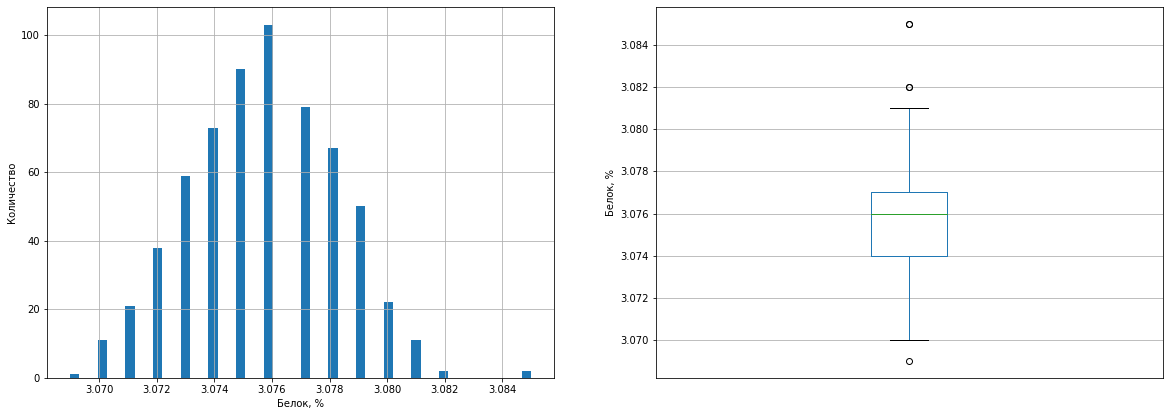

In [49]:
counting_param(ferma_main, 'protein', 'Белок, %','Количество')

Из представленных гистограмм и диаграмм размахов видно следующее: выбросы в данных есть, но не везде; некоторые столбцы "чисты" - то есть там нет выбросов. Можно обработать выброс в столбце `'milk_yield'`, так как он один и это удаление правильнее определит некоторые параметры описательных характеристик столбца, так как этот выброс отличается на несколько порядков. Выбросов в столбце `'fat_content'` много, это видно; однако удалять эти данные не стоит, так как из гистограммы видно, что распределение - "аномально", не похоже ни на одно из существующих и не "нормально"; к тому же в нашем небольшом датафрейме удаление большого числа выбросов может также негативно отразиться на будущем исследовании. Выбросы в столбце `'protein'`не критичны и их крайне мало; из гистограммы видно, что там нормальное распределение, поэтому их также можно оставить.

In [50]:
# удаляем выброс в столбце 'milk_yield'
ferma_main = ferma_main.drop(ferma_main[ferma_main['milk_yield'] == 45616].index).reset_index(drop=True)

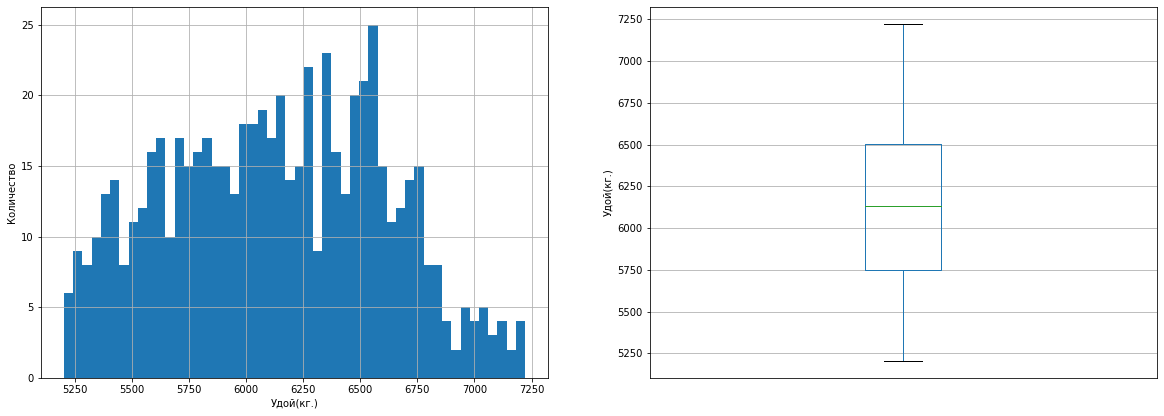

In [51]:
counting_param(ferma_main, 'milk_yield', 'Удой(кг.)','Количество')

Теперь в данных столбца `'milk_yield'` выбросов не наблюдается.

Снова вызовем функцию `counting_param()`, но уже к каждому столбцу датафрейма `cow_buy`, содержащим количественные переменные: 

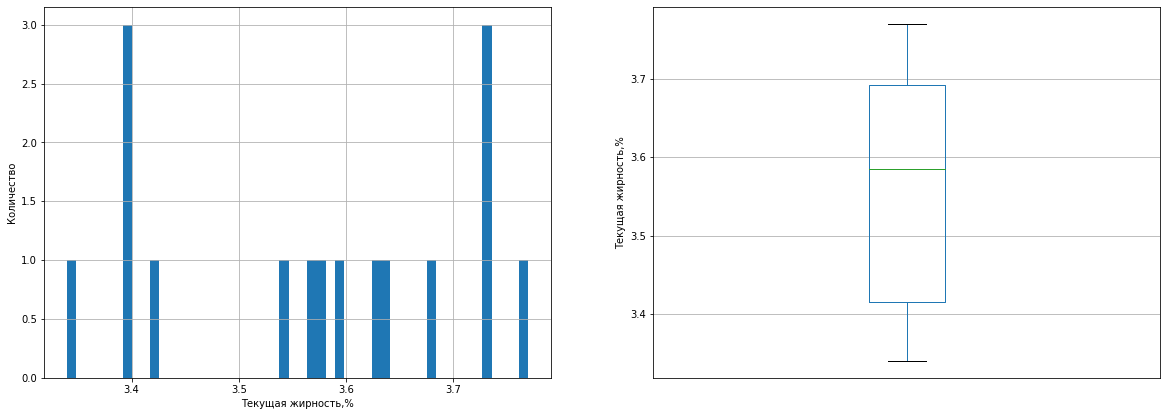

In [52]:
counting_param(cow_buy, 'fat_content', 'Текущая жирность,%','Количество')

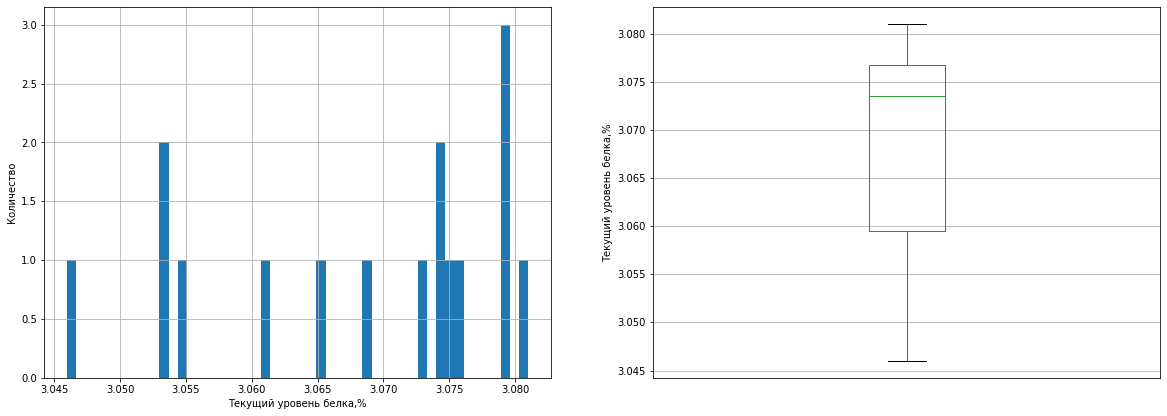

In [53]:
counting_param(cow_buy, 'protein', 'Текущий уровень белкa,%','Количество')

В датафрейме `cow_buy` можно заметить, что нет выбросов данных и распределение гистограммы непонятное, но больше похожее на равномерное.

**Рассмотрим категориальные переменные**

Для того чтобы подсчитать количество значений в конкретном столбце категориальных переменных, воспользуемся методом `.value_counts()`; после для наглядности выведем круговую диаграмму этих значений.

Рассмотрим датафрейм `ferma_dad`:

Барин       240
Буйный      215
Соловчик    110
Геркулес     64
Name: dad_name, dtype: int64

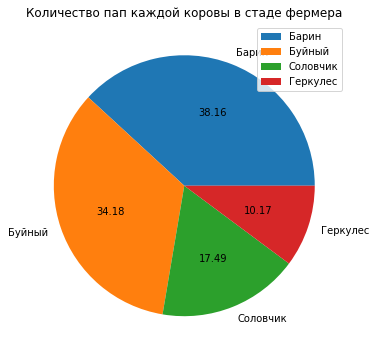

In [54]:
display(ferma_dad['dad_name'].value_counts())
ferma_dad['dad_name'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(8,6))
plt.ylabel(' ')
plt.title('Количество пап каждой коровы в стаде фермера')
plt.legend()
plt.show()

In [55]:
print('Процент количества коров с отцами Барин и Буйный: ',
      ((ferma_dad['dad_name'].value_counts().iloc[0] + ferma_dad['dad_name'].value_counts().iloc[1])/len(ferma_dad)*100).round(2))

Процент количества коров с отцами Барин и Буйный:  72.34


Из полученных результатов можно говорить о том, что быки Барин и Буйный являются отцами для *более 70%* коров на ферме.

Для оптимизации напишем функцию `dataframe_diagram()`, которая будет строить и выводить круговые диаграммы; в функцию будем передавать датафрейм, список необходимых столбцов и список заголовочных названий графиков: 

In [56]:
def dataframe_diagram(dataframe, data_list, title_list):
    for i,j in zip(data_list,title_list):
        dataframe[i].value_counts().plot(kind='pie', autopct='%.2f', figsize=(8,6))
        plt.ylabel(' ')
        plt.title(j)
        plt.legend()
        plt.show()

Применим функцию `dataframe_diagram()` к категориальным данным датафрейма `ferma_main `:

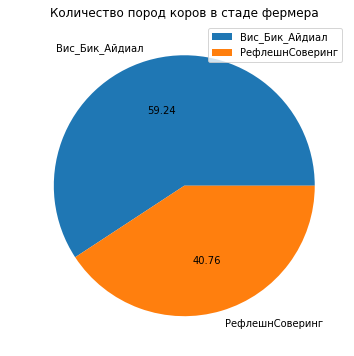

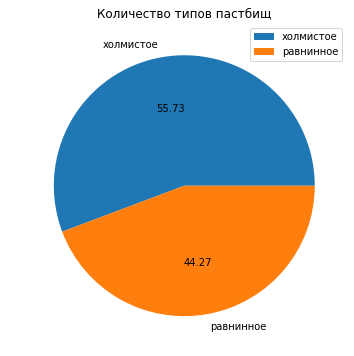

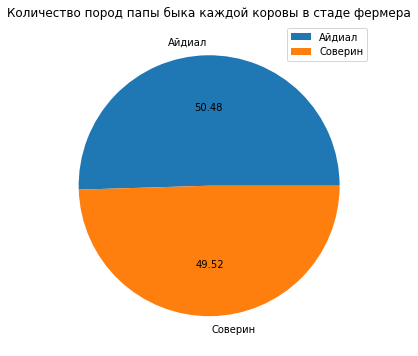

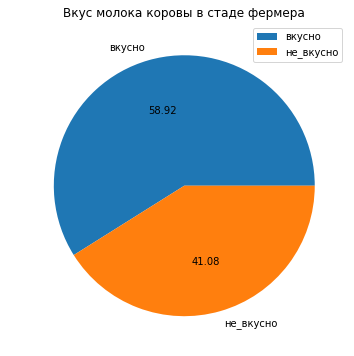

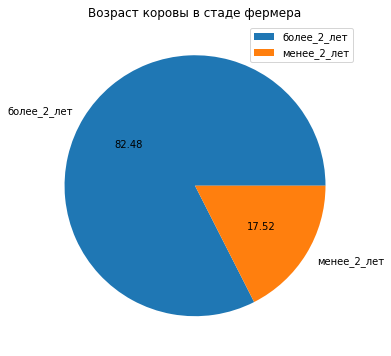

In [57]:
ferma_main_title_list = (['Количество пород коров в стаде фермера','Количество типов пастбищ',
                          'Количество пород папы быка каждой коровы в стаде фермера','Вкус молока коровы в стаде фермера',
                          'Возраст коровы в стаде фермера'])

dataframe_diagram(ferma_main, ferma_main.drop(columns = ferma_main.describe().columns).columns, ferma_main_title_list)

Из визуализации результатов видно следующее:
- Около 60% коров в стаде фермера имеют породу Вис Бик Айдиал
- Типы пастбищ распределены практически на равные части
- Порода папы быка каждой коровы в стаде фермера имеют равное соотношение: либо Айдиал, либо Соверин
- Почти 60% коров в стаде фермера дают вкусное молоко
- Более 80% имеют возраст более двух лет

Теперь применим функцию `dataframe_diagram()` к категориальным данным датафрейма `cow_buy `:

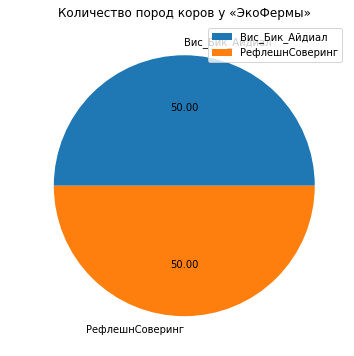

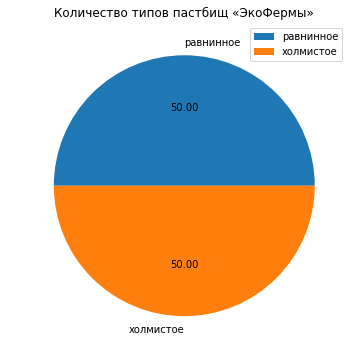

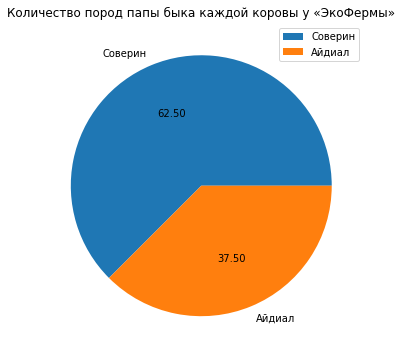

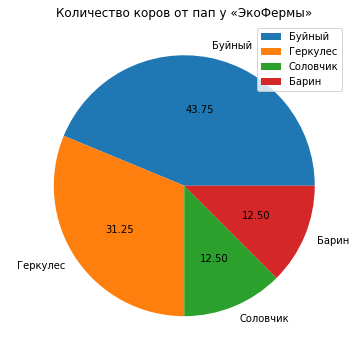

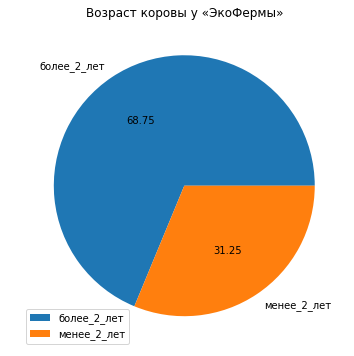

In [58]:
cow_buy_title_list = (['Количество пород коров у «ЭкоФермы»','Количество типов пастбищ «ЭкоФермы»',
                       'Количество пород папы быка каждой коровы у «ЭкоФермы»','Количество коров от пап у «ЭкоФермы»',
                       'Возраст коровы у «ЭкоФермы»'])

dataframe_diagram(cow_buy, cow_buy.drop(columns = cow_buy.describe().columns).columns, cow_buy_title_list)

Из визуализированных данных можно сказать следующее:
- Процентное соотношение пород коров и типов пастбищ у «ЭкоФермы» разделено поровну - 50/50
- Более 60% пород папы быка является *Соверин* для коров у «ЭкоФермы»
- Бык Буйный является отцом для большинства коров «ЭкоФермы» - 43.75% - в то время как Геркулес, Барин и Соловчик имеют лишь 31.25%, 12.5% и 12.5% соответственно.
- Около 70% коров у «ЭкоФермы» имеют возраст более двух лет

#### Сделаем выводы о данных:

В результате исследования количественных признаков были получены следующие результаты:
- были замечены выбросы в некоторых признаках(Удой, Жирность и Белок), в основном данные "чистые" - без выбросов
- из построенных гистограмм можно говорить о том, что практически все признаки имеют не нормальное распределение - у каких-то признаков график похож на экспоненциальное, или Хи-квадрат, или равномерное; нормальное распределение имеет только признак Белок, что наблюдается из гистограммы
- было принято решение не удалять выбросы в признаках Жирность и Белок, так как признак Жирность имеет много выбросов и из гистограммы видно, что распределение - "аномально" - не похоже ни на одно из существующих и не "нормально", то есть результат удаления может не привести к улучшению модели; а Белок имеет нормальное распределения и слишком малое количество выбросов, что мало вероятно повлияет на улучшение модели, после их удаления. 

В результате исследования категориальных признаков были получены следующие результаты:
- количество пастбищ разделено на равные части и у фермера, и у «ЭкоФермы» - равнинное и холмистое
- 60% коров в стаде фермера имеют породу *Вис Бик Айдиал*, в то время как у «ЭкоФермы» только 50%
- более 60% пород папы быка является *Соверин* для коров у «ЭкоФермы», а у фермера - 50%
- почти 60% коров в стаде фермера дают вкусное молоко
- больше половины коров и у фермера, и у «ЭкоФермы» имеют возраст *более двух лет*
- бык Буйный является отцом для весомой части коров как у фермера, так и у «ЭкоФермы»  


**Промежуточный вывод:**

В результате исследовательского анализа данных было сделано следующее:
- изучены статистические характеристики датафреймов `ferma_main` и `cow_buy` - в `ferma_dad` отсутствовали количественные переменные
- построены гистограммы и диаграммы размаха для каждой количественной переменной
- из построенных гистограмм можно говорить о том, что практически все признаки имеют не нормальное распределение - у каких-то признаков график похож на экспоненциальное, или Хи-квадрат, или равномерное; нормальное распределение имеет только признак Белок, что наблюдается из гистограммы
- было принято решение не удалять выбросы в признаках Жирность и Белок, так как признак Жирность имеет много выбросов и из гистограммы видно, что распределение - "аномально" - не похоже ни на одно из существующих и не "нормально", то есть результат удаления может не привести к улучшению модели; а Белок имеет нормальное распределения и слишком малое количество выбросов
- количество пастбищ разделено на равные части и у фермера, и у «ЭкоФермы»
- 60% коров в стаде фермера имеют породу *Вис Бик Айдиал*, в то время как у «ЭкоФермы» только 50%
- более 60% пород папы быка является *Соверин* для коров у «ЭкоФермы», а у фермера - 50%
- почти 60% коров в стаде фермера дают вкусное молоко
- больше половины коров и у фермера, и у «ЭкоФермы» имеют возраст *более двух лет*
- бык Буйный является отцом для весомой части коров как у фермера, так и у «ЭкоФермы» 


## 4. Корреляционный анализ

#### Проведём корреляционный анализ признаков в датасете `ferma_main`

Изучим взаимосвязь между признаками в датафрейме `ferma_main` - рассчитаем коэффициенты корреляции между всеми признаками. Для этого воспользуемся методом `.corr()`, который возвращает коэффициент корреляции; перед этим удалим столбец `'id'`, так как он лишь показывает уникальный идентификатор коровы, который никак не связан с остальными столбцами. Для анализа корреляции данных в метод `.corr()` передадим `'spearman'` - коэффициент Спирмена, так как не все признаки имеют нормальное распределение:

In [59]:
ferma_main.drop(columns='id').corr('spearman')

,milk_yield,eke,raw_protein,spo,fat_content,protein
milk_yield,1.000000,0.765144,0.437543,0.787904,0.688506,-0.005701
eke,0.765144,1.000000,0.384747,0.741962,0.686973,-0.013321
raw_protein,0.437543,0.384747,1.000000,0.485890,0.392822,0.229051
spo,0.787904,0.741962,0.485890,1.000000,0.701044,0.109924
fat_content,0.688506,0.686973,0.392822,0.701044,1.000000,0.043125
protein,-0.005701,-0.013321,0.229051,0.109924,0.043125,1.000000


Чтобы было проще работать с получившейся матрицей корреляции - построим тепловую карту; применим метод `heatmap` из библиотеки `seaborn`; первым аргументом передадим нашу матрицу, после зададим параметр `annot = True` -  для отображения коэффициентов на карте, и `fmt='.3f'` - чтобы оставить только три знака после запятой у коэффициентов:

<AxesSubplot:>

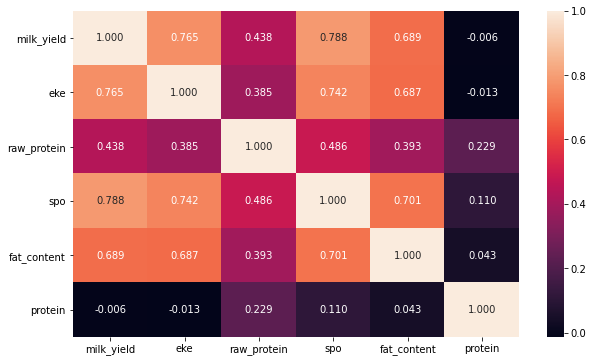

In [60]:
plt.figure(figsize=(10, 6))
sns.heatmap(ferma_main.drop(columns='id').corr('spearman'), annot=True, fmt='.3f')

На тепловой карте удобно представлены результаты, по которым можно провести анализ. Согласно *шкале Чеддока* можно говорить о следующее: связь **высокая** между количественными признаками `milk_yield`,`eke`,`spo`, **заметная** - между `milk_yield`,`eke`,`spo` и `fat_content`; `raw_protein` имеет **слабую связь** со всеми количественными параметрами датафрейма; признак `protein` вообще никак не коррелируют или имеет **очень слабую связь**.

#### Построим диаграммы рассеяния `scatterplot`

Для оптимизации и упрощения работы напишем функцию, которая будет строить диаграмму рассеяния `scatterplot` - `category_scatter()`. Данная функция принимает следующие параметры: `dataframe` - датафрейм с необходимыми данными, `x_value` - столбец данных из переданного датафрейма для оси абсцисс, `y_value` - столбец данных из переданного датафрейма для оси ординат, `categ` - столбец-категорию, относительно которой рассматриваем рассеивание, `name_x` - название оси абсцисс, `name_y` - название оси ординат, `name_title` - заголовок для графика рассеивания.

In [61]:
def category_scatter(dataframe, x_value, y_value, categ, name_x, name_y, name_title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=dataframe, x=x_value, y=y_value, hue=categ, palette='bright')
    # palette - подсвечивает указанную категорию разным цветом
    plt.title(name_title)
    plt.xlabel(name_x)
    plt.ylabel(name_y)
    plt.legend()
    plt.show()

Теперь запишем в переменные `count_values` и `categ_values` количественные и категориальные признаки датасета соответственно (из `count_values` удалим столбцы `'id'` и `'milk_yield'`, так как `'id'` - ни о чем говорить не будет, это просто порядковый номер, а `'milk_yield'` - уже зафиксирован для оси ордината):

In [62]:
count_values = ferma_main.drop(columns = ['id', 'milk_yield']).describe().columns
categ_values = ferma_main.drop(columns = ferma_main.describe().columns).columns

Далее создадаим переменные `x_axis`, `graph_title`, `categor_name`, в которые поместим название оси абсцисс, заголовки графиков рассеивания и названия столбцов категориальных переменных соответственно. После с помощью цикла *`for`* вызовем функцию `category_scatter()` для каждого количественного признака с учётом также категориальных. Далее ознакомимся с результатами вывода:

Вид связи в подгруппах:  порода


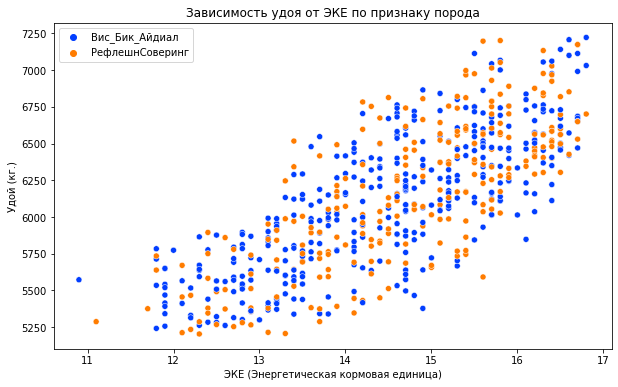

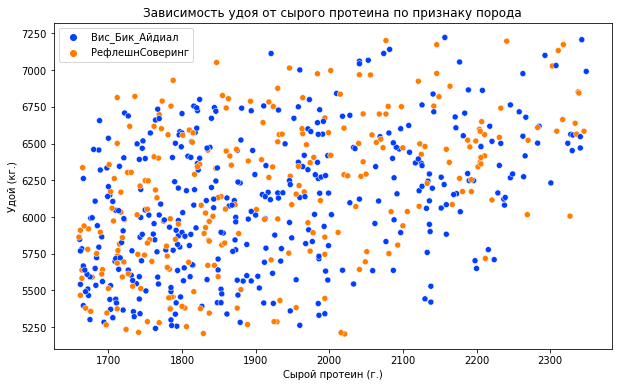

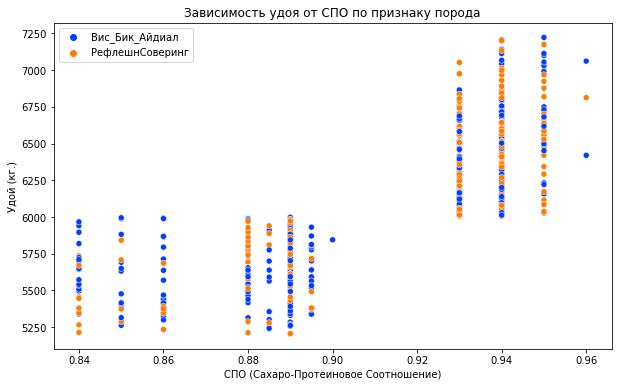

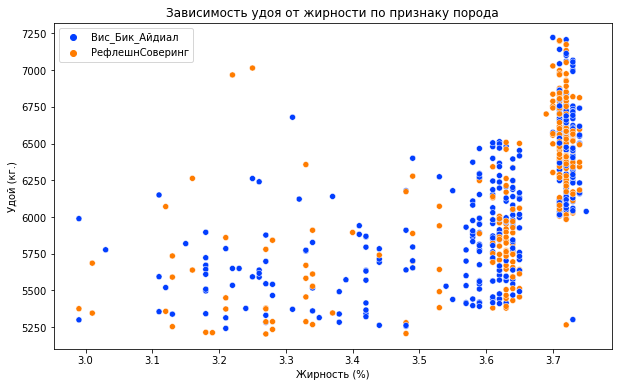

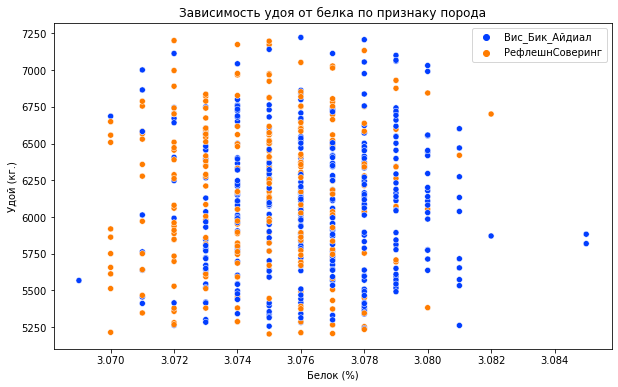

Вид связи в подгруппах:  тип пастбища


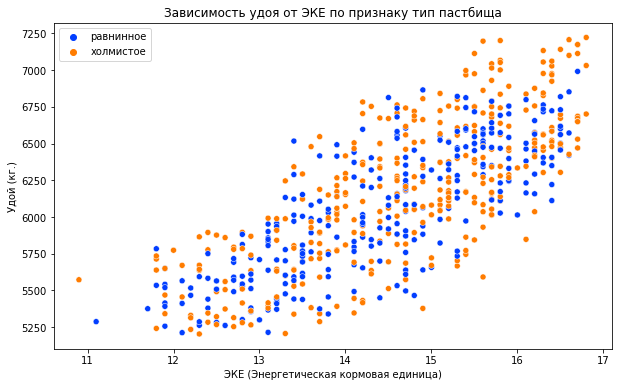

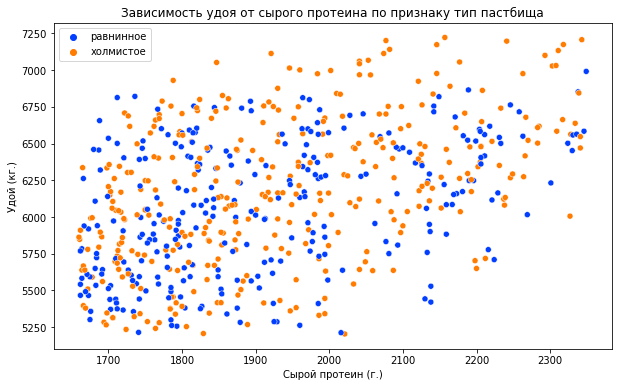

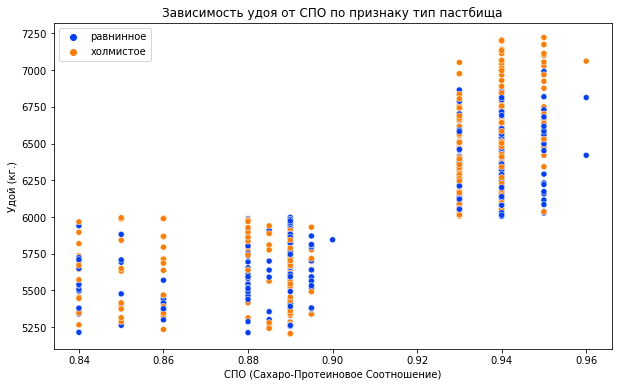

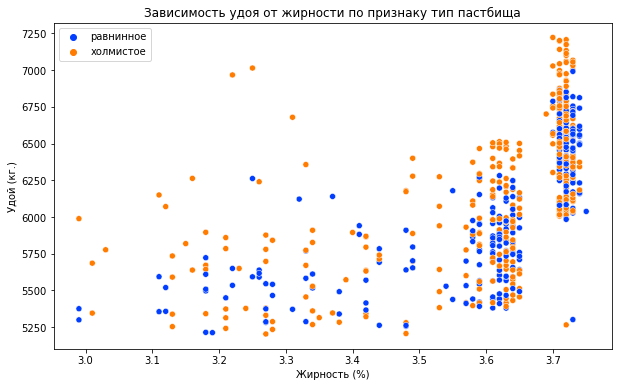

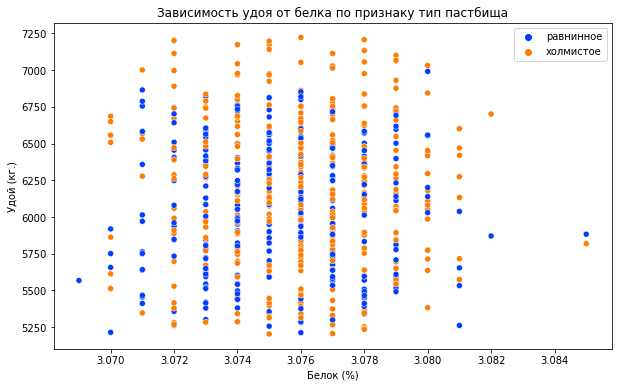

Вид связи в подгруппах:  порода папы быка


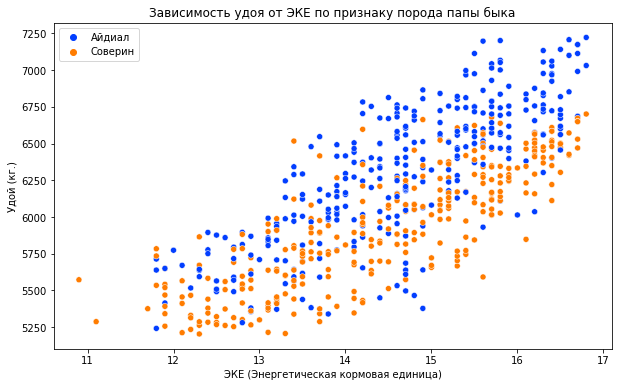

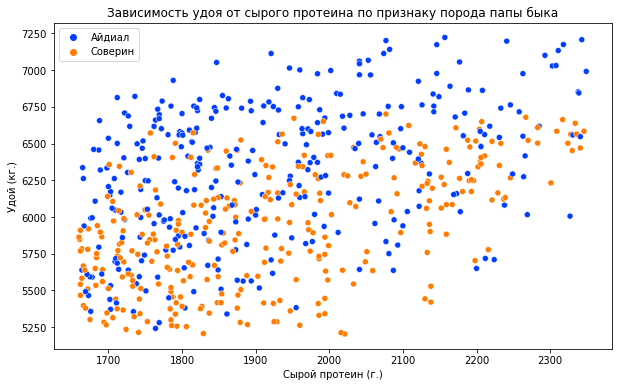

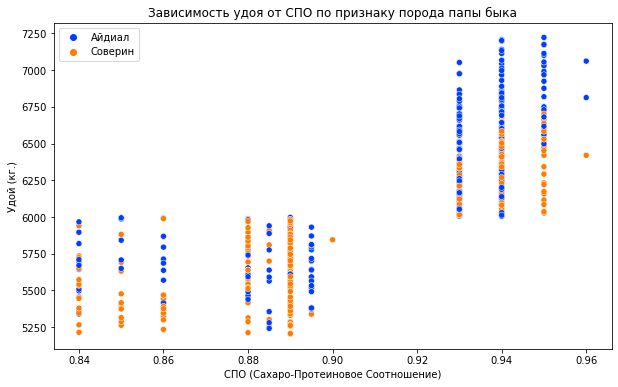

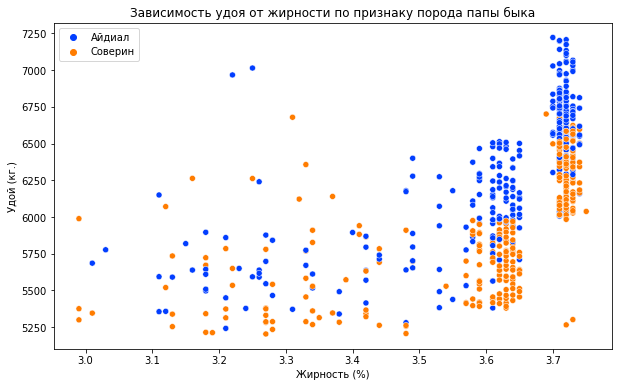

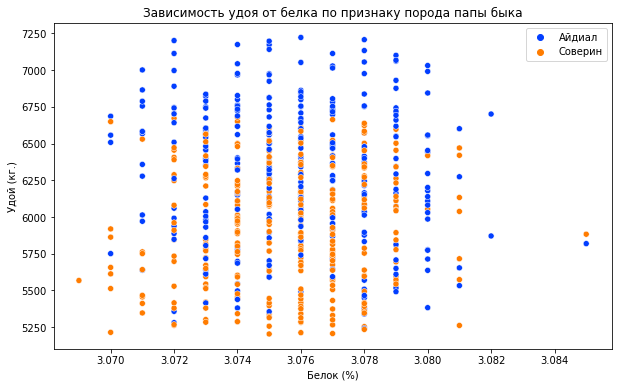

Вид связи в подгруппах:  вкус молока


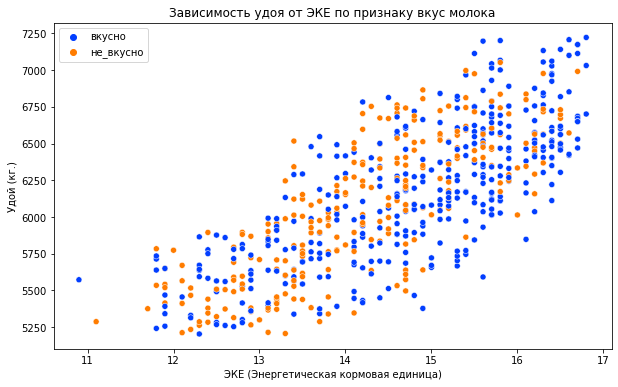

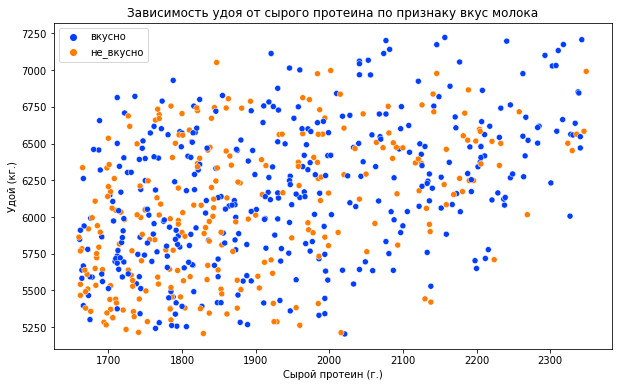

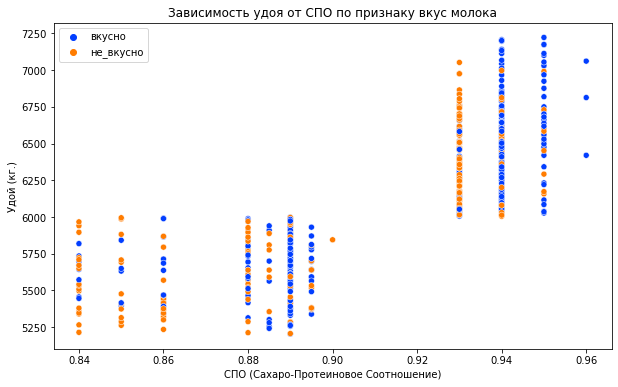

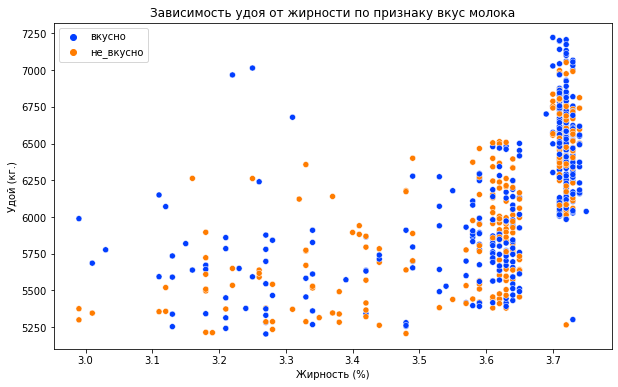

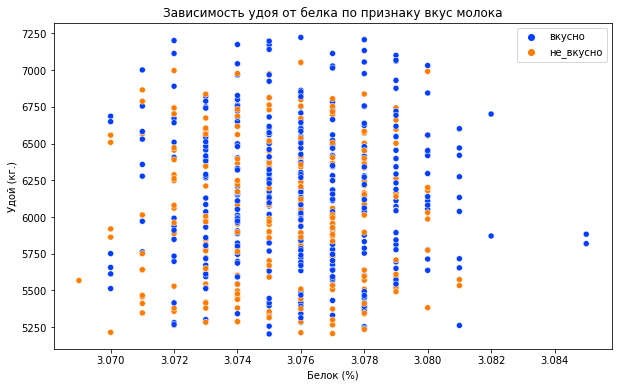

Вид связи в подгруппах:  возраст


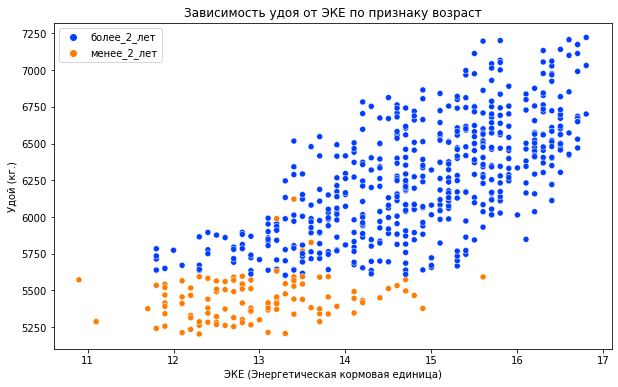

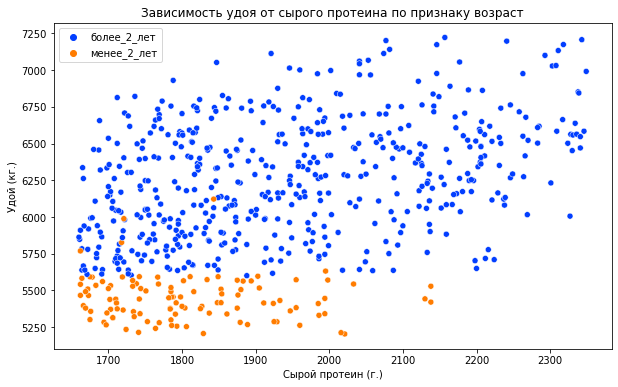

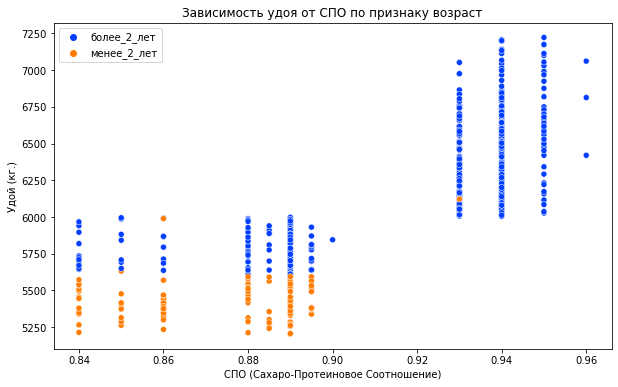

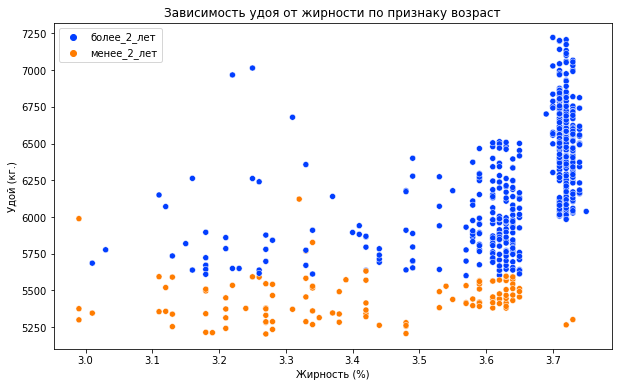

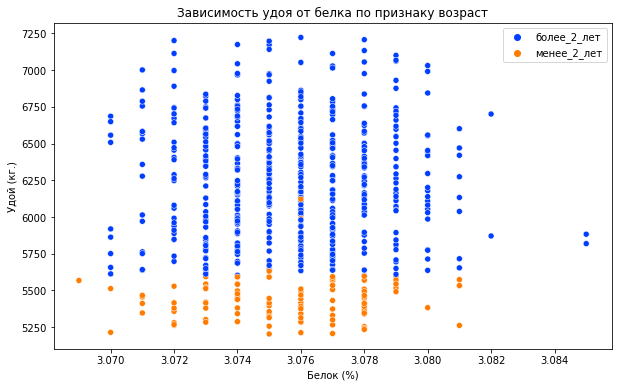

In [63]:
x_axis = (['ЭКЕ (Энергетическая кормовая единица)', 'Сырой протеин (г.)', 'СПО (Сахаро-Протеиновое Соотношение)', 
          'Жирность (%)', 'Белок (%)'])
graph_title = (['Зависимость удоя от ЭКЕ по признаку ', 'Зависимость удоя от cырого протеина по признаку ', 'Зависимость удоя от СПО по признаку ',
               'Зависимость удоя от жирности по признаку ', 'Зависимость удоя от белка по признаку '])
categor_name = ['порода', 'тип пастбища', 'порода папы быка', 'вкус молока', 'возраст']

flag = 0
for i,j in zip(categ_values,categor_name):
    print('Вид связи в подгруппах: ', j)
    for k in count_values:
        category_scatter(ferma_main, k, 'milk_yield', i, x_axis[flag], 'Удой (кг.)', graph_title[flag] + j)
        flag += 1
    flag = 0

**Анализ графиков**:

Из визуализированных графиков можно сказать следующее:
- Между удоем и ЭКЭ наглядно видна линейная зависимость
- СПО можно определенно разделить на 2 кластера и определить границу для этого распределения - 0.92
- Во всех видах связи, кроме возраста, рассеянние смешаны друг с другом
- При разделении с категориальным признаком "Возраст" видно:
    - при СПО (отношение сахара к протеину в корме коровы) выше 0.92 в основном кластер составляют коровы старше 2 лет;
    - удой коров младше двух лет не более 5750 килограмм;
    - в остальных диаграммах распределение в основном по всей области отрезка данных 

#### Сделаем выводы о взаимосвязи признаков:

1. Между целевым(Удоем) и входными признаками наблюдается разные типы взаимосвязи: между Удоем -- ЭКЕ и Удоем -- СПО наблюдается **высокая** связь; **заметная** - между Удоем, ЭКЕ, СПО и Жирностью; Сырой белок имеет **слабую** связь, а Белок имеет **очень слабую** связь.

2. Из тепловой карты можно наблюдать признаки, которые имеют очень *малую* корреляцию, следовательно, обладают **нелинейной** связью. О нелинейной связи можно говорить между Удоем (целевой признак) и Сырым белком и Белком. Определять необходимость ввода дополнительных признаков будем правильнее при построении модели, так как эти признаки могут просто напросто не влиять на качество модели и правильность её работы, а могут и вообще негативно влиять на модель и эти признаки придётся удалить.   

3. Также стоиит отметить, что между некоторыми входными признаками наблюдается мультиколлинеарность, то есть коэффициент корреляции более 0.7. Такая зависимость наблюдается из тепловой таблицы между признаками ЭКЕ и СПО - 0.742. 

**Промежуточный вывод:**

В результате корреляционного анализ данных было проделано следующее:
- построили тепловую карту матрицы корреляционных значений и проанализировали 
- построили диаграммы рассеяния с учётом каждого категориального признака
- проанализировали графики и определили:
    - Между удоем и ЭКЭ наглядно видна линейная зависимость
    - СПО можно определенно разделить на 2 кластера и определить границу для этого распределения - 0.92
    - Во всех видах связи, кроме возраста, рассеянние смешаны друг с другом
    - При разделении с категориальным признаком "Возраст" видно:
        - при СПО (отношение сахара к протеину в корме коровы) выше 0.92 в основном кластер составляют коровы старше 2 лет;
        - удой коров младше двух лет не более 5750 килограмм;
        - в остальных диаграммах распределение в основном по всей области отрезка данных     
- сделали выводы о взаимосвязи признаков

## 5. Обучение модели линейной регрессии

#### Первая линейная модель

Подготовим данные датасета `ferma_main` и обучиим на них первую модель; в качестве целевого признака возьмём  `Удой` - `'milk_yield'`. В качестве входных признаков передадим все столбцы датафрейма, кроме тех, у которых коэффициент корреляции крайне близоу к нулю - то есть не будем учитывать столбцы `'id'` и `'protein'`. Остальные признаки либо имеют сильную линейную зависимость, либо может иметься причинно-следственная связь, к примеру от типа пастбища и возраста зависит будет молоко вкусным или нет. В случае чего, всегда можно удалить или добавить признаки, чтобы понять как модель работает. Несмотря на то, что в корреляционном анализе мы определили, какие признаки имеют линейную связь, а какие - нет; не стоит сразу убирать те, которые не имеют связи, так как это может повлиять на обучаемую модель и снизить её качество. 

Приступим к создании модели:

In [64]:
# создание константы RANDOM_STATE
RANDOM_STATE = 42

# Сохранение входных и целевых признаков X_1 и y_1 соответственно
X_1 = ferma_main.drop(columns=['id','protein','milk_yield'])
y_1 = ferma_main['milk_yield']

Зададим переменной `RANDOM_STATE` значение `42`. Это будет необходимо для дальнейшего использования в функции `train_test_split()`, чтобы при каждом перезапуске датасет делился на выборки одинаково. В переменную `y_1` запишем целевой признак - столбец `'milk_yield'` с данными об удоях в киллограммах, а в `Х_1` - входные признаки. 

In [65]:
# Деление и сохранение на тренировочную и тестовую выборки
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1, y_1, random_state=RANDOM_STATE)

In [66]:
# список всех категориальных признаков из тренировочной выборки
cat_col_names = ['breed', 'pasture_type', 'pasture_breed_dad', 'taste_of_milk', 'age']

# список всех количественных признаков из тренировочной выборки
num_col_names = ['eke', 'raw_protein', 'spo', 'fat_content']

In [67]:
## Подготовка признаков (кодирование)

# Выберем класс OneHotEncoder() для кодирования 
# Зададим параметру sparse значение False для облегчения изучения результатов визуально
encoder = OneHotEncoder(drop='first', sparse=False)

# Обучим и преобразуем категориальные признаки
X_1_train_ohe = encoder.fit_transform(X_1_train[cat_col_names])
X_1_test_ohe = encoder.transform(X_1_test[cat_col_names])

# Сохраним названия новых столбцов в переменную encoder_col_names
encoder_col_names = encoder.get_feature_names()

In [68]:
## Подготовка признаков (масштабирование)

# Создадим переменную с экземпляром класса StandardScaler()
scaler = StandardScaler()

# Обучим и трансформируем количественные признаки
X_1_train_scaled = scaler.fit_transform(X_1_train[num_col_names])
X_1_test_scaled = scaler.transform(X_1_test[num_col_names])

In [69]:
# Создадим тренировочный и тестовый датафреймы из закодированных и отмасштабированных данных
X_1_train_ohe = pd.DataFrame(X_1_train_ohe, columns=encoder_col_names)
X_1_test_ohe = pd.DataFrame(X_1_test_ohe, columns=encoder_col_names)

X_1_train_scaled = pd.DataFrame(X_1_train_scaled, columns=num_col_names)
X_1_test_scaled = pd.DataFrame(X_1_test_scaled, columns=num_col_names)

In [70]:
# Объединяем все преобразованные данные в тренировочный и тестовый датафреймы
X_1_train = pd.concat([X_1_train_ohe, X_1_train_scaled], axis=1)
X_1_test = pd.concat([X_1_test_ohe, X_1_test_scaled], axis=1)

In [71]:
# Инициализируем модель линейной регрессии
model_lr = LinearRegression()

# Обучим модель на тренировочных данных
model_lr.fit(X_1_train, y_1_train)

# Получим предсказания модели на тестовых данных 
# и сохраним результат в predictions_1
predictions_1 = model_lr.predict(X_1_test)

Были получены предсказания модели на тестовых данных. 

*Оценим качество модели на тестовой выборке:* 
- рассчитаем коэффициент детерминации R²  
- проанализируем остатки с помощью графиков

In [72]:
# Рассчитаем значения R2 для модели
r2_1 = r2_score(y_1_test, predictions_1)
print('R2 1st model = ', r2_1.round(4))

R2 1st model =  0.7943


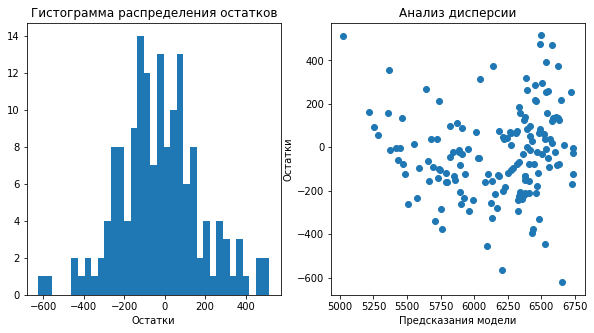

In [73]:
# Проведём анализ остатков
# Рассчитаем остатки
residuals_1 = y_1_test - predictions_1

# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# Гистограмма частотности распределения
axes[0].hist(residuals_1, bins = 35)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

# Диаграмма рассеяния
axes[1].scatter(predictions_1, residuals_1)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

**Выводы по первой обученной модели:**
- значение коэффициента детерминации R² близко к единице, то есть модель хорошо себя показывает в 79% случаев
- график анализа остатков немного, но всё же имеет асимметричное нормальное распределение со смещением влево, что является не очень хорошим признаком, так как модель часто даёт слишком большие предсказания - её прогнозы больше истинных значений

В дальнейшем постараемся улучшить модель, увеличить коэффициент детерминации R² и свести график анализа остатков к симметричному нормальному распределению. Дополнительные исследования определенно нужны, так как модель скорее всего может показывать результаты лучше, а также нужно проверять все возможные варианты, чтобы получить наболее точные предсказания и значение R² было близко к единице.

#### Вторая линейная модель

Для начала необходимо подготовить данные с учётом связи входных признаков с целевым; из диаграмм рассеяния можно увидеть, что некоторые входные признаки связаны с целевым нелинейно, поэтому исключим нелинейность, чтобы эти признаки были информативны для линейной регрессии. 

Для этого сделаем следующее:
- СПО и Удой связаны нелинейно - на диаграмме рассеяния наблюдения сгруппированы в два кластера; устраним нелинейность, преобразовав СПО в категориальный бинарный признак - то есть используя границу между кластерами - 0.91
- ЭКЕ и Удой также связаны нелинейно, поэтому нелинейность между ними исключим, путём ввода нового признака ЭКЕ в квадрате

**Начнём подготовку данных**

С помощью метода `.copy()` скопируем датафрейм `ferma_main`, чтобы не затирать и не портить исходные данные, в переменную `datafr_mod_2`:

In [74]:
datafr_mod_2 = ferma_main.copy()

In [75]:
# Преобразуем СПО в категориальный бинарный признак, используя границу между кластерами 0.91
datafr_mod_2['spo'] = datafr_mod_2['spo'].apply(lambda x: 'ниже_границы' if x < 0.91 else 'выше_границы')

In [76]:
# Вводим новый признак ЭКЕ в квадрате
datafr_mod_2['square_eke'] = datafr_mod_2['eke'].apply(lambda x: x**2)

Теперь удалим из датафрейма те признаки, у которых осталась нелинейная связь:

In [77]:
datafr_mod_2 = datafr_mod_2.drop(columns=['eke', 'raw_protein', 'protein'])

In [78]:
datafr_mod_2.head(1)

,id,milk_yield,spo,breed,pasture_type,pasture_breed_dad,fat_content,taste_of_milk,age,square_eke
0,1,5863,ниже_границы,Вис_Бик_Айдиал,равнинное,Айдиал,3.58,вкусно,более_2_лет,201.64


В качестве целевого признака, как и в прошлой модели, возьмём  `Удой` - `'milk_yield'`. В качестве входных признаков передадим столбцы датафрейма, которые имеют линейную связь, то есть коэффициент корреляции более 0.5, а также новые созданные признаки, то есть не будем учитывать столбцы `'id'`,`'protein'`,`'eke'`, `'raw_protein'`. Остальные признаки либо имеют линейную зависимость, либо могут иметь причинно-следственную связь, к примеру от СПО выше границы и возраста зависит будет молоко вкусным или нет.

Приступим к создании модели:

In [79]:
# создание константы RANDOM_STATE
RANDOM_STATE = 42

# Сохранение входных и целевых признаков X_2 и y_2 соответственно
X_2 = datafr_mod_2.drop(columns=['id','milk_yield'])
y_2 = datafr_mod_2['milk_yield']

In [80]:
# Деление и сохранение на тренировочную и тестовую выборки
X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2, y_2, random_state=RANDOM_STATE)

In [81]:
# список всех категориальных признаков из тренировочной выборки
cat_col_names_2 = ['spo', 'breed', 'pasture_type', 'pasture_breed_dad', 'taste_of_milk', 'age']

# список всех количественных признаков из тренировочной выборки
num_col_names_2 = ['square_eke', 'fat_content']

In [82]:
## Подготовка признаков (кодирование)

# Выберем класс OneHotEncoder() для кодирования 
# Зададим параметру sparse значение False для облегчения изучения результатов визуально
encoder = OneHotEncoder(drop='first', sparse=False)

# Обучим и преобразуем категориальные признаки
X_2_train_ohe = encoder.fit_transform(X_2_train[cat_col_names_2])
X_2_test_ohe = encoder.transform(X_2_test[cat_col_names_2])

# Сохраним названия новых столбцов в переменную encoder_col_names_2
encoder_col_names_2 = encoder.get_feature_names()

In [83]:
## Подготовка признаков (масштабирование)

# Создадим переменную с экземпляром класса StandardScaler()
scaler = StandardScaler()

# Обучим и трансформируем количественные признаки
X_2_train_scaled = scaler.fit_transform(X_2_train[num_col_names_2])
X_2_test_scaled = scaler.transform(X_2_test[num_col_names_2])

In [84]:
# Создадим тренировочный и тестовый датафреймы из закодированных и отмасштабированных данных
X_2_train_ohe = pd.DataFrame(X_2_train_ohe, columns=encoder_col_names_2)
X_2_test_ohe = pd.DataFrame(X_2_test_ohe, columns=encoder_col_names_2)

X_2_train_scaled = pd.DataFrame(X_2_train_scaled, columns=num_col_names_2)
X_2_test_scaled = pd.DataFrame(X_2_test_scaled, columns=num_col_names_2)

In [85]:
# Объединяем все преобразованные данные в тренировочный и тестовый датафреймы
X_2_train = pd.concat([X_2_train_ohe, X_2_train_scaled], axis=1)
X_2_test = pd.concat([X_2_test_ohe, X_2_test_scaled], axis=1)

In [86]:
# Инициализируем модель линейной регрессии
model_lr = LinearRegression()

# Обучим модель на тренировочных данных
model_lr.fit(X_2_train, y_2_train)

# Получим предсказания модели на тестовых данных 
# и сохраним результат в predictions_2
predictions_2 = model_lr.predict(X_2_test)

Были получены предсказания модели на тестовых данных. 

*Оценим качество модели на тестовой выборке:* 
- рассчитаем коэффициент детерминации R²  
- проанализируем остатки с помощью графиков

In [87]:
# Рассчитаем значения R2 для модели
r2_2 = r2_score(y_2_test, predictions_2)
print('R2 2nd model = ', r2_2.round(4))


R2 2nd model =  0.8157


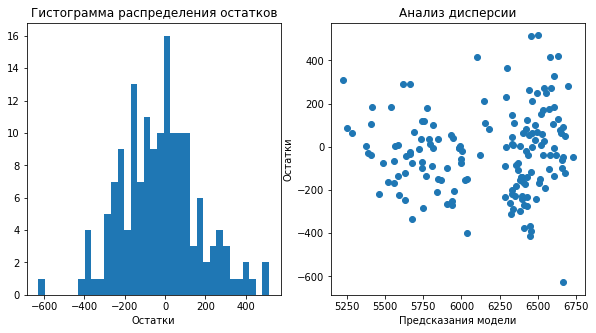

In [88]:
# Проведём анализ остатков
# Рассчитаем остатки
residuals_2 = y_2_test - predictions_2

# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# Гистограмма частотности распределения
axes[0].hist(residuals_2, bins = 35)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

# Диаграмма рассеяния
axes[1].scatter(predictions_2, residuals_2)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

**Выводы по второй обученной модели:**
- значение коэффициента детерминации R² увеличился по сравнению с прошлой моделью и также близок к единице - теперь модель хорошо себя показывает в 81.5% случаев
- график анализа остатков также изменился и в лучшую сторону, теперь он имеет симметричное нормальное распределение, то есть  среднее значение остатков модели равно 0. Из этого можно говорить, что разница между истинными значениями и предсказанными принимает как положительные, так и отрицательные значения - модель даёт предсказания, которые «уравновешивают» друг друга

Несмотря на то, что модель удалось улучшить на 2.5%, попробуем её улучшить ещё больше. Постараемся улучшить модель, увеличить коэффициент детерминации R² и свести график анализа остатков к симметричному нормальному распределению.

#### Третья линейная модель

Для начала необходимо снова подготовить данные: возьмём датафрейм прошлой модели, который показал себя очень даже хорошо и уже исключает нелинейность между признаками, и добавим в данные новый признак `Имя Папы` из датафрейма `ferma_dad`. 

**Начнём подготовку данных**

С помощью метода `.merge()` объединим датафрейм `datafr_mod_2` и `ferma_dad` по ключу `on='id'`и сохраним получившийся результат в переменную `datafr_mod_3`:


In [89]:
datafr_mod_3 = datafr_mod_2.merge(ferma_dad, on='id')

Выведем первые строки, чтобы проверить правильно ли произошло объединение:

In [90]:
datafr_mod_3.head(3)

,id,milk_yield,spo,breed,pasture_type,pasture_breed_dad,fat_content,taste_of_milk,age,square_eke,dad_name
0,1,5863,ниже_границы,Вис_Бик_Айдиал,равнинное,Айдиал,3.58,вкусно,более_2_лет,201.64,Буйный
1,2,5529,ниже_границы,Вис_Бик_Айдиал,равнинное,Соверин,3.54,вкусно,менее_2_лет,163.84,Соловчик
2,3,5810,ниже_границы,РефлешнСоверинг,холмистое,Соверин,3.59,не_вкусно,более_2_лет,196.00,Барин


В качестве целевого признака, как и в прошлой модели, возьмём  `Удой` - `'milk_yield'`. В качестве входных признаков передадим столбцы датафрейма, которые имеют линейную связь, то есть коэффициент корреляции более 0.5, а также новые созданные признаки, то есть не будем учитывать столбцы `'id'`,`'protein'`,`'eke'`, `'raw_protein'`. Остальные признаки либо имеют линейную зависимость, либо могут иметь причинно-следственную связь, к примеру от процента жирности зависит будет молоко вкусным или нет. Теперь в категориальные признаки добавился столбец `'dad_name'`.

Приступим к создании модели:

In [91]:
# создание константы RANDOM_STATE
RANDOM_STATE = 42

# Сохранение входных и целевых признаков X_3 и y_3 соответственно
X_3 = datafr_mod_3.drop(columns=['id','milk_yield'])
y_3 = datafr_mod_3['milk_yield']

In [92]:
# Деление и сохранение на тренировочную и тестовую выборки
X_3_train, X_3_test, y_3_train, y_3_test = train_test_split(X_3, y_3, random_state=RANDOM_STATE)

In [93]:
# список всех категориальных признаков из тренировочной выборки
cat_col_names_3 = ['spo', 'breed', 'pasture_type', 'pasture_breed_dad', 'taste_of_milk', 'age', 'dad_name']

# список всех количественных признаков из тренировочной выборки
num_col_names_3 = ['square_eke', 'fat_content']

In [94]:
## Подготовка признаков (кодирование)

# Выберем класс OneHotEncoder() для кодирования 
# Зададим параметру sparse значение False для облегчения изучения результатов визуально
encoder = OneHotEncoder(drop='first', sparse=False)

# Обучим и преобразуем категориальные признаки
X_3_train_ohe = encoder.fit_transform(X_3_train[cat_col_names_3])
X_3_test_ohe = encoder.transform(X_3_test[cat_col_names_3])

# Сохраним названия новых столбцов в переменную encoder_col_names_3
encoder_col_names_3 = encoder.get_feature_names()

In [95]:
## Подготовка признаков (масштабирование)

# Создадим переменную с экземпляром класса StandardScaler()
scaler = StandardScaler()

# Обучим и трансформируем количественные признаки
X_3_train_scaled = scaler.fit_transform(X_3_train[num_col_names_3])
X_3_test_scaled = scaler.transform(X_3_test[num_col_names_3])

In [96]:
# Создадим тренировочный и тестовый датафреймы из закодированных и отмасштабированных данных
X_3_train_ohe = pd.DataFrame(X_3_train_ohe, columns=encoder_col_names_3)
X_3_test_ohe = pd.DataFrame(X_3_test_ohe, columns=encoder_col_names_3)

X_3_train_scaled = pd.DataFrame(X_3_train_scaled, columns=num_col_names_3)
X_3_test_scaled = pd.DataFrame(X_3_test_scaled, columns=num_col_names_3)

In [97]:
# Объединяем все преобразованные данные в тренировочный и тестовый датафреймы
X_3_train = pd.concat([X_3_train_ohe, X_3_train_scaled], axis=1)
X_3_test = pd.concat([X_3_test_ohe, X_3_test_scaled], axis=1)

In [98]:
# Инициализируем модель линейной регрессии
model_lr = LinearRegression()

# Обучим модель на тренировочных данных
model_lr.fit(X_3_train, y_3_train)

# Получим предсказания модели на тестовых данных 
# и сохраним результат в predictions_3
predictions_3 = model_lr.predict(X_3_test)

Были получены предсказания модели на тестовых данных. 

*Оценим качество модели на тестовой выборке:* 
- рассчитаем коэффициент детерминации R²  
- проанализируем остатки с помощью графиков

In [99]:
# Рассчитаем значения R2 для модели
r2_3 = r2_score(y_3_test, predictions_3)
print('R2 3rd model = ', r2_3.round(4))

R2 3rd model =  0.8221


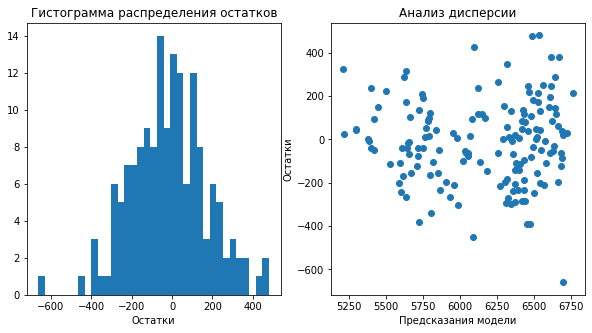

In [100]:
# Проведём анализ остатков
# Рассчитаем остатки
residuals_3 = y_3_test - predictions_3

# Построим графики
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# Гистограмма частотности распределения
axes[0].hist(residuals_3, bins = 35)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

# Диаграмма рассеяния
axes[1].scatter(predictions_3, residuals_3)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

**Выводы по третьей обученной модели:**
- значение коэффициента детерминации R² ещё увеличилось по сравнению с прошлыми моделями и также близок к единице - теперь модель хорошо себя показывает в 82.2% случаев
- график анализа остатков изменился, он также имеет симметричное нормальное распределение, то есть среднее значение остатков модели равно 0. Из этого можно говорить, что разница между истинными значениями и предсказанными принимает как положительные, так и отрицательные значения - модель даёт предсказания, которые «уравновешивают» друг друга


#### Сравним качество трёх моделей линейной регрессии

Сравним качество трёх моделей линейной регрессии, сопоставьте их R² и остатки:

In [101]:
print('Коэффициент детерминации R² 1ой модели: ', r2_1.round(4))
print('Коэффициент детерминации R² 2ой модели: ', r2_2.round(4))
print('Коэффициент детерминации R² 3ей модели: ', r2_3.round(4))
print('Сумма остатков 1ой модели: ', residuals_1.sum().round(2))
print('Сумма остатков 2ой модели: ', residuals_2.sum().round(2))
print('Сумма остатков 3ей модели: ', residuals_3.sum().round(2))
print('Абсолютная сумма остатков 1ой модели: ', abs(residuals_1).sum().round(2))
print('Абсолютная сумма остатков 2ой модели: ', abs(residuals_2).sum().round(2))
print('Абсолютная сумма остатков 3ей модели: ', abs(residuals_3).sum().round(2))

Коэффициент детерминации R² 1ой модели:  0.7943
Коэффициент детерминации R² 2ой модели:  0.8157
Коэффициент детерминации R² 3ей модели:  0.8221
Сумма остатков 1ой модели:  -4058.24
Сумма остатков 2ой модели:  -3760.17
Сумма остатков 3ей модели:  -2215.04
Абсолютная сумма остатков 1ой модели:  25052.83
Абсолютная сумма остатков 2ой модели:  23679.09
Абсолютная сумма остатков 3ей модели:  23459.92


По результатам сравнения можно говорить о том, что *третья модель* обучена лучше всего, так как коэффициент детерминации R² больше, чем у всех других моделей - это говорит о том, насколько хорошо модель "объясняет", предсказывает целевой признак по входным - и в её случае это 82.2%, а также сумма остатков у третьей модели как простых, так и абсолютных меньше, чем у предыдущих моделей. **Однако** пока предположим эту версию, так как необходимо посмотреть ещё и на осталльные метрики моделей.

#### Оценим качество каждой модели

Оценим качество каждой модели по трём метрикам: MSE, MAE, RMSE. Используйте функции для расчёта метрик.
Выберите лучшую модель;
Укажите доверительный интервал прогноза лучшей модели. Для этого рассчитайте квантили ошибки модели на тренировочных данных.

Для того чтобы каждый раз не писать одно и тоже создадим функцию для расчёта метрик MSE, MAE, RMSE `define_metric()`, куда будем передавать `y_test` - тестовые данные и `predictions` - предсказанные данные:

In [102]:
def define_metric(y_test, predictions):
    # Посчитаем среднюю абсолютную ошибку (MAE)
    mae = mean_absolute_error(y_test, predictions)
    print('MAE модели = ', mae.round(3))

    # Посчитаем значениe MSE
    mse = mean_squared_error(y_test, predictions)
    print('MSE модели = ', mse.round(3))

    # Посчитаем значениe RMSE
    rmse = mean_squared_error(y_test, predictions, squared=False)
    print('RMSE модели = ', rmse.round(3))

Теперь применим эту функцию и посмотрим на результаты вывода для метрик по всем трём моделям:

In [103]:
print('Линейная модель 1:')
define_metric(y_1_test, predictions_1)
print('Линейная модель 2:')
define_metric(y_2_test, predictions_2)
print('Линейная модель 3:')
define_metric(y_3_test, predictions_3)

Линейная модель 1:
MAE модели =  159.572
MSE модели =  41876.771
RMSE модели =  204.638
Линейная модель 2:
MAE модели =  150.822
MSE модели =  37509.38
RMSE модели =  193.673
Линейная модель 3:
MAE модели =  149.426
MSE модели =  36213.161
RMSE модели =  190.298


Из результатов расчёта метрик можно сказать, что метрики третьей модели самые низкие, чем у других моделей, а это означает, что модель лучше других может предсказывать целевой признак. Из этого следует, что, как мы ранее и предполагали,  *третья модель* обучена лучше всего, поэтому с ней дальше и продолжим работать. 

**Определим доверительный интервал**

Для этого сделаем следующее:

В `mean_pred` запишем pасчет среднего значения предсказаний `predictions_3`:

In [104]:
mean_pred = np.mean(predictions_3)

После этого проведём расчет стандартной ошибки среднего и запишем результат в `sem_pred`:

In [105]:
sem_pred = sem(predictions_3)

Далее проведём расчет поправки на уровень доверия и запишем результат в `margin_of_error`:

In [106]:
margin_of_error = norm.ppf(0.975) * sem_pred

В конце найдём нижнюю и верхнюю границы доверительного интервала:

In [107]:
lower_bound = mean_pred - margin_of_error
upper_bound = mean_pred + margin_of_error

print(f'Доверительный интервал лучшей модели = {lower_bound.round(4)}, {upper_bound.round(4)}')
print(f'Размер доверительного интервала лучшей модели = {(upper_bound - lower_bound).round()}')

Доверительный интервал лучшей модели = 6091.5444, 6219.9848
Размер доверительного интервала лучшей модели = 128.0


Было определено, что доверительный интервал равен 128. Этот результат будет необходим нам в конце исследования, так как, когда будем объединять результаты прогноза по Удоям с результатами прогнозов по Вкусу, то сделаем поправку на этот доверительный интервал.

#### Спрогнозируем удой коров

С помощью лучшей модели, которую мы определили ранее, спрогнозируем Удой коров, которых фермер хочет купить. Данные для этого возьмём из датафрейма `cow_buy`.

Добавим в него недостающие признаки: `ЭКЕ (Энергетическая кормовая единица)`, `Сырой протеин, г` и `СПО (Сахаро-протеиновое соотношение)` - а также те признаки, которые были добавлены в лучшей модели. Для `ЭКЕ`, `Сырой протеин` и `СПО` возьмём из датафрейма `ferma_main` средние значения каждого из признаков и увелим их на 5%. После этого подготовим данные и получим прогноз Удоя коров.

Начнём с добавления нужных признаков в датафрейм:

С помощью метода `.copy()` скопируем датафрейм `cow_buy` в новую переменную `cow_buy_prog`:

In [108]:
cow_buy_prog = cow_buy.copy()

Добавим необходимые и недостающие признаки в `cow_buy_prog` и после выведем первые строки, чтобы убедиться в их записи в датафрейм:

In [109]:
cow_buy_prog['eke'] = ferma_main['eke'].mean() * 1.05
cow_buy_prog['square_eke'] = cow_buy_prog['eke'] * cow_buy_prog['eke']
cow_buy_prog['spo'] = ferma_main['spo'].mean() * 1.05
cow_buy_prog['spo_categ'] = cow_buy_prog['spo'].apply(lambda x: 'ниже_границы' if x < 0.91 else 'выше_границы')
cow_buy_prog['raw_protein'] = ferma_main['raw_protein'].mean() * 1.05
cow_buy_prog.head(3)

,breed,pasture_type,pasture_breed_dad,dad_name,fat_content,protein,age,eke,square_eke,spo,spo_categ,raw_protein
0,Вис_Бик_Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,233.361138,0.958744,выше_границы,2019.947532
1,Вис_Бик_Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,233.361138,0.958744,выше_границы,2019.947532
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.276162,233.361138,0.958744,выше_границы,2019.947532


Теперь скопируем и сохраним датафрейм прошлой модели в `datafr_mod_lin`, а также добавим и переименнуем некоторые столбцы: 

In [110]:
datafr_mod_lin = datafr_mod_3.copy()
# Переименование столбца внутри DataFrame
datafr_mod_lin.rename(columns={'spo': 'spo_categ'}, inplace=True)
datafr_mod_lin['spo'] = ferma_main['spo'] 
datafr_mod_lin.head(2)

,id,milk_yield,spo_categ,breed,pasture_type,pasture_breed_dad,fat_content,taste_of_milk,age,square_eke,dad_name,spo
0,1,5863,ниже_границы,Вис_Бик_Айдиал,равнинное,Айдиал,3.58,вкусно,более_2_лет,201.64,Буйный,0.89
1,2,5529,ниже_границы,Вис_Бик_Айдиал,равнинное,Соверин,3.54,вкусно,менее_2_лет,163.84,Соловчик,0.89


В качестве целевого признака для тренировочной выборки укажем `'milk_yield'` - `Удой`, который нам и необходимо будет предсказать в тестовой выборке. В качестве входных признаков передадим датафрейм `datafr_mod_lin` и удалим из него следующие признаки, так как они никак не влияют на результаты модели: `'id'`,`'pasture_breed_dad'`, `'dad_name'`, `'breed'`. В качестве входных признаков для тестовых данных передадим датафрейм `cow_buy_prog`. 

Приступим к создании модели:

In [111]:
# Сохранение входных и целевых признаков
X_train_final = datafr_mod_lin.drop(columns=['id','pasture_breed_dad', 'dad_name', 'breed','milk_yield'])
y_train_final = datafr_mod_lin['milk_yield']
X_test_final = cow_buy_prog

Определим списки категориальных и количественных признаков: в категориальные отнесём столбцы с данными `'spo_categ'` и `'pasture_type'`, так как от них влияет результат и разделение СПО на категории помогло улучшить прошлые модели, а в количественные - те данные, которые себя хорошо показали на прошлой модели и имеют заметную/высокую линейную связь:

In [112]:
# список всех категориальных признаков 
cat_col_names_final = ['spo_categ', 'pasture_type']

# список всех количественных признаков
num_col_names_final = ['square_eke', 'spo', 'fat_content']

In [113]:
## Подготовка признаков (кодирование)

# Выберем класс OneHotEncoder() для кодирования 
# Зададим параметру sparse значение False для облегчения изучения результатов визуально
encoder = OneHotEncoder(drop='first', sparse=False)

# Обучим и преобразуем категориальные признаки
X_train_final_ohe = encoder.fit_transform(X_train_final[cat_col_names_final])
X_test_final_ohe = encoder.transform(X_test_final[cat_col_names_final])

# Сохраним названия новых столбцов в переменную encoder_col_names_final
encoder_col_names_final = encoder.get_feature_names()

In [114]:
## Подготовка признаков (масштабирование)

# Создадим переменную с экземпляром класса StandardScaler()
scaler = StandardScaler()

# Обучим и трансформируем количественные признаки
X_train_final_scaled = scaler.fit_transform(X_train_final[num_col_names_final])
X_test_final_scaled = scaler.transform(X_test_final[num_col_names_final])

In [115]:
# Создадим тренировочный и тестовый датафреймы из закодированных и отмасштабированных данных
X_train_final_ohe = pd.DataFrame(X_train_final_ohe, columns=encoder_col_names_final)
X_test_final_ohe = pd.DataFrame(X_test_final_ohe, columns=encoder_col_names_final)

X_train_final_scaled = pd.DataFrame(X_train_final_scaled, columns=num_col_names_final)
X_test_final_scaled = pd.DataFrame(X_test_final_scaled, columns=num_col_names_final)

In [116]:
# Объединяем все преобразованные данные 
X_train_final = pd.concat([X_train_final_ohe, X_train_final_scaled], axis=1)
X_test_final = pd.concat([X_test_final_ohe, X_test_final_scaled], axis=1)

In [117]:
# Инициализируем модель линейной регрессии
model_lr = LinearRegression()

# Обучим модель на тренировочных данных
model_lr.fit(X_train_final, y_train_final)

# Получим предсказания модели на тестовых данных 
# и сохраним результат в predictions_1
predictions_final = model_lr.predict(X_test_final)
predictions_final

array([6454.31572786, 6403.29226043, 6413.6226592 , 6417.12629227,
       6423.95305798, 6421.88697822, 6409.49049969, 6417.12629227,
       6485.30692419, 6442.54777577, 6474.97652541, 6421.25845178,
       6417.12629227, 6485.30692419, 6450.81209479, 6361.97066533])

После обучения модели и предсказания результата тестовых данных, можно наблюдать, что прогноз по Удою коров, которые рассматриваются к покупке почти у всех *более* 6400 килограмм, что довольно хорошо.

**Промежуточный вывод:**

В результате обучение моделей линейных регрессий было получено следующее:
- были обучены 3 модели линейной регрессии
- для каждой модели были определены входные и целевой признаки
- было проведено сравнение качества трёх моделей по метрикам: коэффициент детерминации R², MAE, MSE, RMSE
- провели также анализ остатков модели с помощью графиков
- определён доверительный интервал
- выбрана линейная модель, которая показала себя лучше всего
- были спрогнозированы Удои коров, которых фермер планирует покупать 

## 6. Обучение модели логистической регрессии

#### Логистическая модель

Теперь рассмотрим задачу классификации. Сделаем всё тоже самое что и раньше для линейной модели, но только теперь для логистической, а после проанализируем.

Начнём с подготовки данных:

Скопируем необходимые нам данные из датафрейма `ferma_main` в `logist_df`:

In [118]:
logist_df = ferma_main.copy()

Закодируем целевой признак `Вкус молока` - `'taste_of_milk'` - где `1` - `вкусно`, а `0` - `не вкусно`:

In [119]:
logist_df['taste_of_milk'] = logist_df['taste_of_milk'].apply(lambda x: 1 if x == "вкусно" else 0)

Выведем первые строки датафрейма:

In [120]:
logist_df.head()

,id,milk_yield,eke,raw_protein,spo,breed,pasture_type,pasture_breed_dad,fat_content,protein,taste_of_milk,age
0,1,5863,14.2,1743,0.890,Вис_Бик_Айдиал,равнинное,Айдиал,3.58,3.076,1,более_2_лет
1,2,5529,12.8,2138,0.890,Вис_Бик_Айдиал,равнинное,Соверин,3.54,3.079,1,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,0,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,холмистое,Айдиал,3.40,3.075,0,более_2_лет
4,5,5302,12.8,1675,0.885,Вис_Бик_Айдиал,равнинное,Соверин,3.73,3.073,1,менее_2_лет


Определим признаки модели:

В качестве целевого признака возьмём  `Вкус молока` - `'taste_of_milk'`. В качестве входных признаков передадим такие, которые будут показывать как можно больший параметр точности `accuracy`, то есть все столбцы данных, кроме `'id'`, `'breed'`, `'taste_of_milk'`.

Приступим к создании модели:

In [121]:
RANDOM_STATE = 42
X = logist_df.drop(columns=['id', 'breed', 'taste_of_milk'])
y = logist_df['taste_of_milk']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

In [122]:
# список всех категориальных признаков 
cat_col_names_log = ['pasture_breed_dad', 'pasture_type', 'age']

# список всех количественных признаков из тренировочной выборки
num_col_names_log = ['milk_yield', 'eke', 'raw_protein', 'spo', 'fat_content', 'protein']

In [123]:
## Подготовка признаков (кодирование)

# Выберем класс OneHotEncoder() для кодирования 
# Зададим параметру sparse значение False для облегчения изучения результатов визуально
encoder = OneHotEncoder(drop='first', sparse=False)

# Обучим и преобразуем категориальные признаки
X_train_ohe = encoder.fit_transform(X_train[cat_col_names_log])
X_test_ohe = encoder.transform(X_test[cat_col_names_log])

# Сохраним названия новых столбцов в переменную encoder_col_names_log
encoder_col_names_log = encoder.get_feature_names()

In [124]:
## Подготовка признаков (масштабирование)

# Создадим переменную с экземпляром класса StandardScaler()
scaler = StandardScaler()

# Обучим и трансформируем количественные признаки
X_train_scaled = scaler.fit_transform(X_train[num_col_names_log])
X_test_scaled = scaler.transform(X_test[num_col_names_log])

In [125]:
# Создадим тренировочный и тестовый датафреймы из закодированных и отмасштабированных данных
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names_log)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names_log)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names_log)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names_log)

In [126]:
# Объединяем все преобразованные данные в тренировочный и тестовый датафреймы
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

In [127]:
clf = LogisticRegression()
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

Были получены предсказанные результаты Вкуса молока.

Оценим качество модели: рассчитаем метрики *accuracy, recall, precision* и построим матрицу ошибок:

In [128]:
# проводим оценку точности
acc = accuracy_score(y_test, y_pred)
print('accuracy: ', round(acc, 3))

recall = recall_score(y_test, y_pred) # здесь ваш код
precision = precision_score(y_test, y_pred) # здесь ваш код

print('recall: ', round(recall ,3))
print('precision: ', round(precision,3))

accuracy:  0.643
recall:  0.886
precision:  0.629


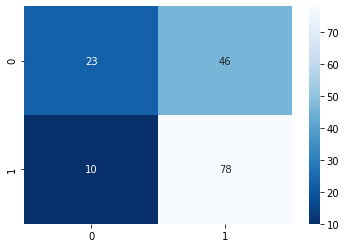

In [129]:
# построим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r');

Из рассчитанных метрик и построенной матрицы ошибок сделаем следующие выводы: 
 - Accuracy - это доля правильных предсказаний среди всех предсказаний, и в нашей модели составляет 64.3%
 - Precision показывает точность, с которой модель присваивает объектам класс `вкусно`, то есть определяет, не слишком ли часто модель выставляет класс `вкусно` объектам класса `не вкусно`
 - Recall - метрика, обратная precision, измеряет, смогла ли модель классификации присвоить класс `вкусно` всем объектам этого класса
 - Из матрицы ошибок видно, что 10 коров, которые были нужны, не были найдены, а 46 коров, которых мы нашли, это не те и дают невкусное молоко

Из данных результатов определим дальнейший ход работы, так как нам важен Вкус молока, то необходимо свести метрику `precision` к максимуму, то есть чтобы ошибок первого рода стало минимальное возможное количество. Именно ошибки первого рода *критичны*, так как нам необходимо держать планку того, что наши коровы дают прежде всего *вкусное* молоко, которое будет нравиться покупателям. Таким образом нам необходимо снизить *FP* - *ошибки 1ого рода* - как можно сильнее, **но** при этом постараться сделать так, чтобы и метрика `аccuracy` не была слишком малой, а лучше если увеличится.

Для лучшего понимания ошибок будем отталкиваться от следующего "правила":
- FP (Ошибка 1го рода) - "нашел, но не тех кого нужно"; из всех предсказаний, что корова даёт вкусное, FP - количество коров, которые по факту дают невкусное
- FN (Ошибка 2го рода) - "не нашел нужных". Из всех предсказанных коров, которых определили как дающих невкусное молоко, FN - количество коров, которые на самом деле давали вкусное

Теперь определим порог классификации, при котором и `precision` высокий, и `аccuracy` не уменьшается:

Получим предсказание к какому классу определят корову, в зависимости от тестовых данных и сформируем датафрейм `data`, в котором будут храниться результаты тестовой выборки и прдсказанных вероятностей. После добавим пороги с помощью функции `linspace` -  разделим заданный промежуток на 100 и посмотрим на то, как модель будет работать при разных порогах:

In [130]:
# Получение вероятностей для тестовой выборки
y_proba = clf.predict_proba(X_test)[:,1]

data = pd.DataFrame(zip(y_test, y_proba),
             columns = ['y_valid', 'y_proba']).sort_values(by='y_proba',ascending=False)


thresholds = [round(i,2) for i in np.linspace(0.1,1,num = 100,endpoint=False)]

Теперь запишем в `data` предсказанные при разном пороге результаты:

In [131]:
# создаём переменную, которая будет хранить список новых колонок
columns = []

# добавим столбцы с новыми предсказаниями
for i in thresholds:
    columns.append('y_pred_'+str(i))
    data['y_pred_'+str(i)] = data['y_proba'].apply(lambda y: 1 if (y > i) else 0)

Рассчитаем метрики *accuracy, recall, precision* при разных порогах классификации: 

In [132]:
recall_col = []
precision_col = []
accuracy_col =[]

for i in thresholds:
    recall = recall_score(data['y_valid'], data['y_pred_'+str(i)]) 
    precision = precision_score(data['y_valid'], data['y_pred_'+str(i)]) 
    accuracy = accuracy_score(data['y_valid'], data['y_pred_'+str(i)])
    recall_col.append(round(recall, 4))
    precision_col.append(round(precision, 4))
    accuracy_col.append(round(accuracy, 4))

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined a

Запишем и преобразуем в датафрейм полученные результаты метрик и выведем их:

In [133]:
df_compare = (pd.DataFrame(data = {'порог':thresholds, 'recall_pr': recall_col, 'precision_pr': precision_col, 'accuracy_pr':accuracy_col})
              .reset_index(drop=True))

In [134]:
df_compare.head()

,порог,recall_pr,precision_pr,accuracy_pr
0,0.10,1.0,0.5605,0.5605
1,0.11,1.0,0.5605,0.5605
2,0.12,1.0,0.5605,0.5605
3,0.13,1.0,0.5605,0.5605
4,0.14,1.0,0.5605,0.5605


Теперь отсортируем столбец `precision_pr`, чтобы посмотреть на характеристики модели при определенном пороге:

In [135]:
df_compare = (pd.DataFrame(data = {'порог':thresholds, 'recall_pr': recall_col, 'precision_pr': precision_col, 'accuracy_pr':accuracy_col})
              .sort_values(by='accuracy_pr',ascending=False).reset_index(drop=True))

In [136]:
df_compare.sort_values(by='precision_pr',ascending=False).head()

,порог,recall_pr,precision_pr,accuracy_pr
80,0.83,0.0341,1.0000,0.4586
81,0.82,0.0341,1.0000,0.4586
82,0.84,0.0227,1.0000,0.4522
75,0.79,0.1250,0.9167,0.5032
78,0.80,0.0909,0.8889,0.4841


Из вывода видно, что при значении `precision` равном `1` точность модели очень сильно падает - практически на 20%. 

Отсортируем датафрейм теперрь по столбцу `accuracy_pr` и посмотрим на то, как там себя ведёт модель при пороге классификации:

In [137]:
df_compare = df_compare.sort_values(by='accuracy_pr',ascending=False)
df_compare.head()

,порог,recall_pr,precision_pr,accuracy_pr
0,0.67,0.5455,0.7869,0.6624
2,0.60,0.7045,0.6966,0.6624
3,0.60,0.7045,0.6966,0.6624
4,0.59,0.7273,0.6882,0.6624
5,0.65,0.6023,0.7465,0.6624


Видно, что при пороге классификации `0.67`, точность модели `accuracy` немного, но всё же увеличилась, а `precision` увеличился на `16%`, что говорит о том, что ошибочно найденных коров стало явно меньше. 

Снова выведем матрицу ошибок и отдельно значения метрик *accuracy, recall, precision* при определенном нами пороге:

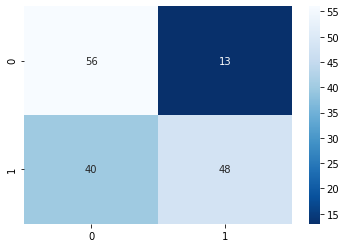

In [138]:
# Задание порога классификации
threshold = df_compare.loc[0, 'порог']

# Преобразование вероятностей в бинарные предсказания
y_pred = (y_proba >= threshold).astype(int)

# построение матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r');

In [139]:
# проводим оценку точности
acc = accuracy_score(y_test, y_pred)
print('accuracy: ', round(acc, 3))

recall = recall_score(y_test, y_pred) # здесь ваш код
precision = precision_score(y_test, y_pred) # здесь ваш код

print('recall: ', round(recall ,3))
print('precision: ', round(precision,3))
# нужно увеличивать precision, то есть уменьшить число коров нашел, но не тех кого нужно, так как важен вкус молока 
# если выкинуть breed, то получается accuracy:  0.662  recall:  0.545   precision:  0.787

accuracy:  0.662
recall:  0.545
precision:  0.787


Из результатов по улучшению порога классификации можно сказать, что при пороге 0.67 метрики `accuracy` и `precision` показывают себя лучше всего, что хорошо, так как это говорит о том, что в около 2 из 3 случаев модель правильно определяет предсказание; и в около 78.7% количество найденных коров, но с невкусным молоком будет минимально. По сравнению с прошлым порогом количество ошибок первого рода было 46, теперь же их удалось снизить до 13, точность модели повысилась на 2%, а полнота упала с 88% до 54.5%, то есть число тех коров, которые были нужны увеличилось. Однако нам стоит помнить, что главное для заказчика **вкусное молоко**.

#### Спрогнозируем вкус молока

С помощью логистической модели, которую мы определили ранее, и с улучшенным порогом классификации спрогнозируем Вкус молока коров, которых фермер хочет купить. Данные для этого возьмём из датафрейма `cow_buy`.

С помощью метода `.copy()` скопируем датафрейм `cow_buy` в новую переменную `cow_buy_logist`:

In [140]:
cow_buy_logist = cow_buy.copy()

Определим признаки модели:

В качестве целевого признака возьмём  `Вкус молока` - `'taste_of_milk'`. В качестве входных признаков передадим данные прошлой логистической модели `logist_df`, а в качестве тестовых данных - `cow_buy_logist`.

Приступим к создании модели:

In [141]:
X_train_logist = logist_df.drop(columns=['id', 'taste_of_milk'])
y_train_logist = logist_df['taste_of_milk']
X_test_logist = cow_buy_logist

Из диаграмм, которые ранее строили можно говорить о том, что по категориальным признакам влияет возраст жирность эке и спо

In [142]:
# список всех категориальных признаков 
cat_col_names_logist = ['pasture_type', 'age']

# список всех количественных признаков из тренировочной выборки
num_col_names_logist = [ 'fat_content']
                        #['eke', 'spo', 'fat_content', 'protein']

In [143]:
## Подготовка признаков (кодирование)

# Выберем класс OneHotEncoder() для кодирования 
# Зададим параметру sparse значение False для облегчения изучения результатов визуально
encoder = OneHotEncoder(drop='first', sparse=False)

# Обучим и преобразуем категориальные признаки
X_train_logist_ohe = encoder.fit_transform(X_train_logist[cat_col_names_logist])
X_test_logist_ohe = encoder.transform(X_test_logist[cat_col_names_logist])

# Сохраним названия новых столбцов в переменную encoder_col_names_log
encoder_col_names_logist = encoder.get_feature_names()

In [144]:
## Подготовка признаков (масштабирование)

# Создадим переменную с экземпляром класса StandardScaler()
scaler = StandardScaler()

# Обучим и трансформируем количественные признаки
X_train_logist_scaled = scaler.fit_transform(X_train_logist[num_col_names_logist])
X_test_logist_scaled = scaler.transform(X_test_logist[num_col_names_logist])

In [145]:
# Создадим тренировочный и тестовый датафреймы из закодированных и отмасштабированных данных
X_train_logist_ohe = pd.DataFrame(X_train_logist_ohe, columns=encoder_col_names_logist)
X_test_logist_ohe = pd.DataFrame(X_test_logist_ohe, columns=encoder_col_names_logist)

X_train_logist_scaled = pd.DataFrame(X_train_logist_scaled, columns=num_col_names_logist)
X_test_logist_scaled = pd.DataFrame(X_test_logist_scaled, columns=num_col_names_logist)

In [146]:
# Объединяем все преобразованные данные в тренировочный и тестовый датафреймы
X_train_logist = pd.concat([X_train_logist_ohe, X_train_logist_scaled], axis=1)
X_test_logist = pd.concat([X_test_logist_ohe, X_test_logist_scaled], axis=1)

In [147]:
# Задание порога классификации
threshold = 0.67

clf = LogisticRegression()
clf = clf.fit(X_train_logist, y_train_logist)
y_probabilities = clf.predict_proba(X_test_logist)[:, 1]
predictions_end = (y_probabilities >= threshold).astype(int)

In [148]:
print('Количество коров с вкусным молоком: ', predictions_end.sum())

Количество коров с вкусным молоком:  4


В результате обучения модели и предсказания данных о коровах, которых фермер хочет купить, получилось, что только 4 коровы, у которых молоко будет вкусным.


**Промежуточный вывод:**

В результате обучение моделей логистических регрессий было получено следующее:
- была обучена модель логистической регрессии
- для модели были определены входные и целевой признаки
- был проведен расчёт метрик *accuracy, recall, precision*
- построена матрица ошибок
- проведён анализ по тому, ошибка какого рода наиболее критична - ошибка 1го рода
- был найден новый порог классификации, который улучшает параметры *accuracy, precision* и снижает ошибки первого рода - 0.67
- с учётом нового порога классификации было спрогнозировано количество коров с вкусным молоком и какие это коровы

## 7. Итоговые выводы

Добавим прогнозы Вкуса молока и Удоя коров «ЭкоФермы» в датафрейм с коровами, покупку которых рассматриваем:

In [149]:
cow_buy['milk_yield']= pd.DataFrame(predictions_final)
cow_buy['taste_of_milk']= pd.DataFrame(predictions_end)

Теперь отберем коров, для которых спрогнозирован удой более 6000 килограммов в год и вкусное молоко.

In [150]:
cow_buy.query('(milk_yield > 6000) & (taste_of_milk == 1)')

,breed,pasture_type,pasture_breed_dad,dad_name,fat_content,protein,age,milk_yield,taste_of_milk
0,Вис_Бик_Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,6454.315728,1
8,Вис_Бик_Айдиал,холмистое,Соверин,Соловчик,3.73,3.055,более_2_лет,6485.306924,1
10,Вис_Бик_Айдиал,холмистое,Айдиал,Геркулес,3.68,3.046,более_2_лет,6474.976525,1
13,Вис_Бик_Айдиал,холмистое,Соверин,Соловчик,3.73,3.079,более_2_лет,6485.306924,1


Коровы из датафрейма с индексами `0`, `8`, `10`, `13` согласно нашим прогнозам подходят для покупки фермеру. Также стоит отметить, что даже с учётом доверительного интервала, который ранее был найден, коровы точно дадут фермеру свыше 6128 килограмм молока(с учётом этого интервала).

**Результаты работы моделей:**

Согласно построенным нами моделям по прогнозу удоя и вкуса коров было найдено 4 коровы, которые точно отвечают требованиям фермера. Модели были построены исходя из данных о коровах, которые уже есть у фермера и характеристик для каждой из них; обучив модели на этих данных, мы получили данные о том, что фермер может купить из стада на продажу с минимальным риском для себя только 4 коровы.

Из анализа при построении моделей можно дать рекомендации фермеру, что при покупке стоит обращать внимание на такие характеристики как возраст, тип пастбища, жирность молока, а также СПО и его категориальный(бинарный) признак.

**Выводы о моделях линейной регрессии и логистической регрессии:**

Для улучшения качества регрессионной модели были использовали следующие способы:
- рассматривались только те признаки, которые имели высокую или заметную линейную зависимость; такие признаки помогают лучше обучить модель и позволить ей делать прогноз точнее; перегружать модель признаками, не имеющими никакой или очень слабой зависимости, всё равно, что ухудшать её качество прогноза
- создание новых признаков, которые положительно влияют на прогноз модели; стоит учитывать, что мы добавляли новые признаки на основе линейной взаимосвязи между ними
- категоризация имеющихся признаков: в ходе исследования в СПО можно было чётко выделить границу и разделить имеющиеся данные на 2 кластера

На мой взгляд результаты регрессионной модели *возможно* улучшить, так как 82.5% ещё не предел возможностей модели; а для улучшения модели от фермера необходимо узнать другие признаки, которые также имеют достаточно хорошую связь между собой - то есть коэффициент корреляции более 0.6, так как исходя из них, можно также создать новые признаки, которые также могут помочь улучшить прогнозмодели.  

При анализе рисков или экономических расчётов важны следующие метрики моделей классификации:
- линейная модель:
    - Коэффициент детерминации R²: мера, которая используется для оценки качества модели регрессии; именно он показывает, насколько хорошо модель обучена и говорит нам о том, стоит ли пытаться искать ещё признаки для её улучшения или можно остановиться
    - Анализ остатков: при анализе графика он должен иметь в лучшем случае симметричное нормальное распределение, то есть среднее значение остатков модели будет равно 0. А из этого можно говорить, что разница между истинными значениями и предсказанными принимает как положительные, так и отрицательные значения - модель даёт предсказания, которые «уравновешивают» друг друга
- логистическая модель:
    - Accuracy(точность) - это доля правильных предсказаний среди всех предсказаний, именно с помощью этой характеристики можно понять насколько точно присваиваются значения предсказываемым данным
    - Precision показывает точность, с которой модель присваивает объектам класс 1, то есть определяет, не слишком ли часто модель выставляет класс 1 объектам класса 0
    - Recall(полнота) - метрика, обратная precision, измеряет, смогла ли модель классификации присвоить класс 1 всем объектам этого класса
    - Матрица ошибок: именно из неё можно понять количество ошибок 1го и 2го рода; FP (Ошибка 1го рода) подразумевает, что мы нашли, но не тех кого нужно; а FN (Ошибка 2го рода) наоборот - не нашли нужных
    - Порог классификации - значение, при котором модель классифицирует данные как принадлежащий к определённому классу; данную метрикау необходимо подбирать, так как в зависимости от данных будет разный порог и именно порог классификации может кардинально менять все выше перечисленные метрики логистической модели, при чем как в лучшую сторону, так и в худшую

***Итоговый вывод по всему исследованию:***
- загрузили CSV-файлы с правильным разделяющим параметром
- изменили названия столбцов - привели к правильному виду записи (латинский алфавит, прописные буквы, "змеевидная" запись(через нижнее подчеркивание))
- преобразовали тип данных определенных столбцов датафреймов `ferma_main` и `cow_buy` к правильному
- обработаны пропуски в столбцах датафреймов - выявили, что их нет
- проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
- удалили дубликаты, которые было возможно
- использовали функции для оптимизации работы
- изучили статистические характеристики датафреймов `ferma_main` и `cow_buy` - в `ferma_dad` отсутствовали количественные переменные
- построили гистограммы и диаграммы размаха для каждой количественной переменной
- из построенных гистограмм можно говорить о том, что практически все признаки имеют не нормальное распределение - у каких-то признаков график похож на экспоненциальное, или Хи-квадрат, или равномерное; нормальное распределение имеет только один признак
- было принято решение не удалять выбросы в признаках Жирность и Белок, так как признак Жирность имеет много выбросов и из гистограммы видно, что распределение - "аномально" - не похоже ни на одно из существующих и не "нормально", то есть результат удаления может не привести к улучшению модели; а Белок имеет нормальное распределения и слишком малое количество выбросов
- количество пастбищ разделено на равные части и у фермера, и у «ЭкоФермы»
- 60% коров в стаде фермера имеют породу *Вис Бик Айдиал*, в то время как у «ЭкоФермы» только 50%
- более 60% пород папы быка является *Соверин* для коров у «ЭкоФермы», а у фермера - 50%
- почти 60% коров в стаде фермера дают вкусное молоко
- больше половины коров и у фермера, и у «ЭкоФермы» имеют возраст *более двух лет*
- бык Буйный является отцом для весомой части коров как у фермера, так и у «ЭкоФермы» 
- построили тепловую карту матрицы корреляционных значений и проанализировали её 
- построили диаграммы рассеяния с учётом каждого категориального признака
- проанализировали графики и определили:
    - Между Удоем и ЭКЭ наглядно видна линейная зависимость
    - СПО можно определенно разделить на 2 кластера и определить границу для этого распределения - 0.92
    - Во всех видах связи, кроме возраста, рассеянние смешаны друг с другом
    - При разделении с категориальным признаком "Возраст" видно:
        - при СПО (отношение сахара к протеину в корме коровы) выше 0.92 в основном кластер составляют коровы старше 2 лет;
        - удой коров младше двух лет не более 5750 килограмм;
        - в остальных диаграммах распределение в основном по всей области отрезка данных     
- сделали выводы о взаимосвязи признаков
- были обучены 3 модели линейной регрессии
- для каждой модели были определены входные и целевой признаки
- было проведено сравнение качества трёх моделей по метрикам: коэффициент детерминации R², MAE, MSE, RMSE
- провели также анализ остатков модели с помощью графиков
- определён доверительный интервал
- выбрана линейная модель, которая показала себя лучше всего
- были спрогнозированы Удои коров, которых фермер планирует покупать 
- была обучена модель логистической регрессии
- для модели были определены входные и целевой признаки
- был проведен расчёт метрик *accuracy, recall, precision*
- построена матрица ошибок
- проведён анализ по тому, ошибка какого рода наиболее критична - ошибка 1го рода
- был найден новый порог классификации, который улучшает параметры *accuracy, precision* и снижает ошибки первого рода - 0.67
- с учётом нового порога классификации было спрогнозировано количество коров с вкусным молоком и какие это коровы